# Binary Bins: Classifier

## 1. Imports

In [1]:
import os
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 2. Dataset Setup

### Dataset Dowload

In [3]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
TRASHNET_DIR = DATA_DIR / "trashnet"

DATA_DIR.mkdir(exist_ok=True)
TRASHNET_DIR.mkdir(exist_ok=True)

print("BASE_DIR =", BASE_DIR)
print("DATA_DIR =", DATA_DIR)
print("TRASHNET_DIR =", TRASHNET_DIR)

BASE_DIR = /home/sagemaker-user/classifier
DATA_DIR = /home/sagemaker-user/classifier/data
TRASHNET_DIR = /home/sagemaker-user/classifier/data/trashnet


In [4]:
if not (TRASHNET_DIR / "dataset-resized").exists():
    !git clone https://github.com/garythung/trashnet.git /tmp/trashnet_repo
    !unzip -q /tmp/trashnet_repo/data/dataset-resized.zip -d {TRASHNET_DIR}
    print("TrashNet downloaded successfully.")
else:
    print("TrashNet already exists.")

TrashNet already exists.


In [5]:
DATASET_DIR = TRASHNET_DIR / "dataset-resized"

print("DATASET_DIR exists:", DATASET_DIR.exists())
print("Classes found:")

for folder in sorted(DATASET_DIR.iterdir()):
    if folder.is_dir():
        print("-", folder.name)

DATASET_DIR exists: True
Classes found:
- cardboard
- glass
- metal
- paper
- plastic
- trash


### Exploratory Data Analysis

In [6]:
classes = sorted([folder.name for folder in DATASET_DIR.iterdir() if folder.is_dir()])

total_images = 0

for class_name in classes:
    class_path = DATASET_DIR / class_name
    num_images = len([img for img in class_path.iterdir() if img.is_file()])
    total_images += num_images

print("Total number of images:", total_images)
print("Number of classes:", len(classes), "\n")
print("Images per class:")
for class_name in classes:
    class_path = DATASET_DIR / class_name
    num_images = len([img for img in class_path.iterdir() if img.is_file()])
    print(f"{class_name}: {num_images}")

Total number of images: 2527
Number of classes: 6 

Images per class:
cardboard: 403
glass: 501
metal: 410
paper: 594
plastic: 482
trash: 137


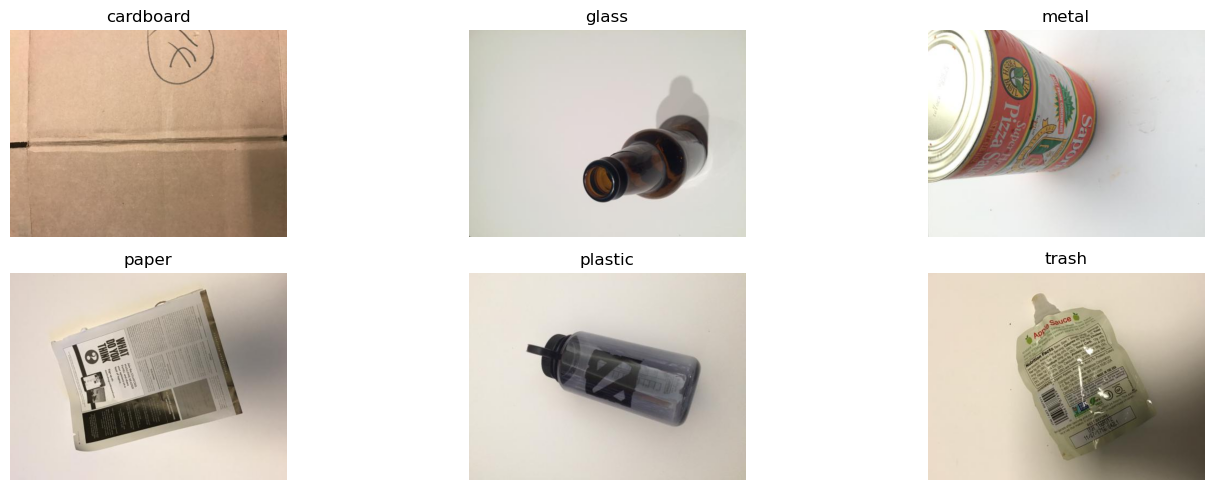

In [7]:
plt.figure(figsize=(15,5))

for i, class_name in enumerate(classes):
    class_path = DATASET_DIR / class_name
    image_names = [img for img in class_path.iterdir() if img.is_file()]
    
    image_path = image_names[0]
    image = Image.open(image_path)
    
    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
invalid_images = []

for class_name in classes:
    class_path = DATASET_DIR / class_name
    
    for image_path in class_path.iterdir():
        if image_path.is_file():
            try:
                img = Image.open(image_path)
                img.verify()
            except:
                invalid_images.append(str(image_path))

print("Number of invalid images:", len(invalid_images))

if len(invalid_images) > 0:
    print("Invalid image files:")
    for file_name in invalid_images:
        print(file_name)

Number of invalid images: 0


In [9]:
image_sizes = []

for class_name in classes:
    class_path = DATASET_DIR / class_name
    
    for image_path in class_path.iterdir():
        if image_path.is_file():
            image = Image.open(image_path)
            image_sizes.append(image.size)

print("Number of images checked:", len(image_sizes))
print("Number of unique image sizes:", len(set(image_sizes)))
print("Image sizes:", set(image_sizes))

Number of images checked: 2527
Number of unique image sizes: 1
Image sizes: {(512, 384)}


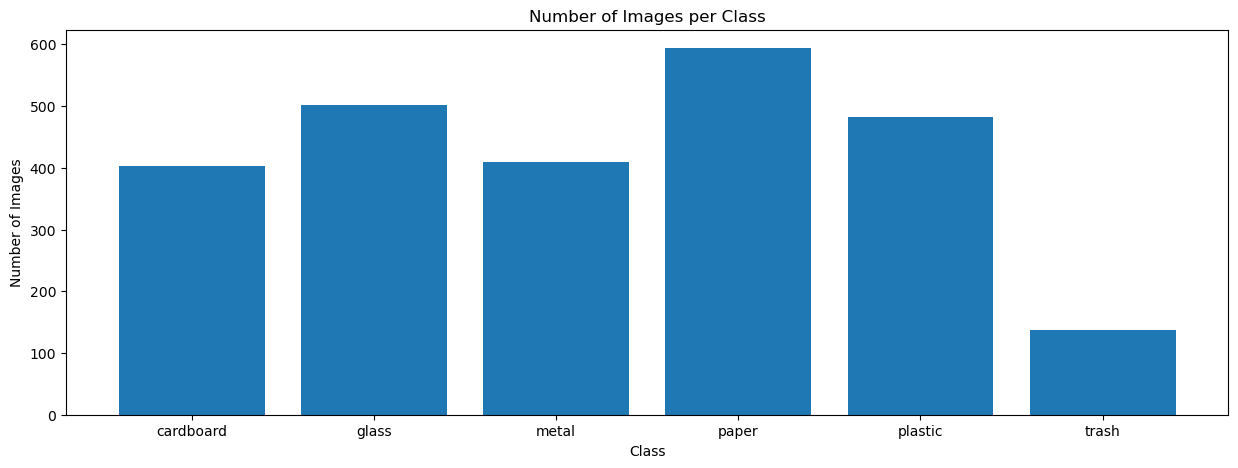

In [10]:
class_counts = []

for class_name in classes:
    class_path = DATASET_DIR / class_name
    num_images = len([img for img in class_path.iterdir() if img.is_file()])
    class_counts.append(num_images)

plt.figure(figsize=(15, 5))
plt.bar(classes, class_counts)
plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [11]:
image_modes = []

for class_name in classes:
    class_path = DATASET_DIR / class_name
    
    for image_path in class_path.iterdir():
        if image_path.is_file():
            image = Image.open(image_path)
            image_modes.append(image.mode)

print("Number of images checked:", len(image_modes))
print("Unique image modes:", set(image_modes))

Number of images checked: 2527
Unique image modes: {'RGB'}


In [12]:
file_names = []

for class_name in classes:
    class_path = DATASET_DIR / class_name
    
    for image_path in class_path.iterdir():
        if image_path.is_file():
            file_names.append(image_path.name)

duplicate_names = [name for name in set(file_names) if file_names.count(name) > 1]

print("Total number of file names:", len(file_names))
print("Number of duplicate file names:", len(duplicate_names))

Total number of file names: 2527
Number of duplicate file names: 0


In [13]:
pixel_min = []
pixel_max = []

for class_name in classes:
    class_path = DATASET_DIR / class_name
    image_list = [img for img in class_path.iterdir() if img.is_file()]
    
    for image_path in image_list[:10]:
        image = Image.open(image_path)
        image_array = np.array(image)
        
        pixel_min.append(image_array.min())
        pixel_max.append(image_array.max())

print("Minimum pixel value:", min(pixel_min))
print("Maximum pixel value:", max(pixel_max))

Minimum pixel value: 0
Maximum pixel value: 255


### Problem Definition

In [14]:
class_names = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

bin_map = {
    'cardboard': 'recyclable',
    'glass': 'recyclable',
    'metal': 'recyclable',
    'paper': 'recyclable',
    'plastic': 'recyclable',
    'trash': 'general_waste'}

bin_names = ['recyclable', 'general_waste']

print("Original classes:", class_names)
print("Final bins:", bin_names)
print("\nClass to bin mapping:")
for class_name in class_names:
    print(f"{class_name} -> {bin_map[class_name]}")

Original classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Final bins: ['recyclable', 'general_waste']

Class to bin mapping:
cardboard -> recyclable
glass -> recyclable
metal -> recyclable
paper -> recyclable
plastic -> recyclable
trash -> general_waste


We will train the classifier on all 6 the original classes, but our final goal is to divide them in the final 2 bins, therefore we implement a manual mapping of each class into the appropriate bin.   

## 3. Data Preparation

### Data Transforms 

In [15]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])])

We applied normalization too in preparation to the pretrained model we will use

### Dataset Loading

In [16]:
full_dataset = datasets.ImageFolder(DATASET_DIR, transform=train_transform)

print("Number of images:", len(full_dataset))
print("Classes:", full_dataset.classes)
print("Class to index:", full_dataset.class_to_idx)

Number of images: 2527
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Class to index: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


### Train, Validation and Test Split

In [17]:
full_dataset_train = datasets.ImageFolder(DATASET_DIR, transform=train_transform)
full_dataset_test = datasets.ImageFolder(DATASET_DIR, transform=test_transform)

indices = torch.randperm(len(full_dataset_train), generator=torch.Generator().manual_seed(SEED)).tolist()

train_size = int(0.7 * len(indices))
val_size = int(0.15 * len(indices))
test_size = len(indices) - train_size - val_size

train_indices = indices[:train_size]
val_indices = indices[train_size:train_size + val_size]
test_indices = indices[train_size + val_size:]

train_dataset = torch.utils.data.Subset(full_dataset_train, train_indices)
val_dataset = torch.utils.data.Subset(full_dataset_test, val_indices)
test_dataset = torch.utils.data.Subset(full_dataset_test, test_indices)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 1768
Validation size: 379
Test size: 380


### Data Loaders

In [18]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 56
Validation batches: 12
Test batches: 12


## 4. Training and Evaluation Functions

Training Function: 

In [19]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    
    running_loss = 0.0
    all_labels = []
    all_preds = []
    
    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        
        _, preds = torch.max(outputs, 1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
    
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='macro')
    
    return epoch_loss, epoch_acc, epoch_f1

Evaluation Function: 

In [20]:
def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    
    running_loss = 0.0
    all_labels = []
    all_preds = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            
            _, preds = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
    
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='macro')
    
    return epoch_loss, epoch_acc, epoch_f1, all_labels, all_preds

Checkpoint:

In [21]:
checkpoint_dir = BASE_DIR / "checkpoints"
checkpoint_dir.mkdir(exist_ok=True)

print("Checkpoint directory:", checkpoint_dir)

Checkpoint directory: /home/sagemaker-user/classifier/checkpoints


## 5. Model Experiments: Non-Augmented Case

### MobileNetV2

#### Model Setup

In [22]:
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, len(class_names))
model = model.to(device)

In [23]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Model: MobileNetV2")
print("Final classifier:", model.classifier)
print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Model: MobileNetV2
Final classifier: Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=6, bias=True)
)
Total parameters: 2231558
Trainable parameters: 2231558


#### Loss Function and Optimizer

In [24]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

checkpoint_path = checkpoint_dir / "mobilenetv2_checkpoint.pth"
best_model_path = checkpoint_dir / "mobilenetv2_best.pth"

#### Training

In [46]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

checkpoint_path = checkpoint_dir / "mobilenetv2_checkpoint.pth"
best_model_path = checkpoint_dir / "mobilenetv2_best.pth"

if checkpoint_path.exists():
    checkpoint_path.unlink()

if best_model_path.exists():
    best_model_path.unlink()

print("MobileNetV2 training setup ready.")
print("Old checkpoints removed.")

MobileNetV2 training setup ready.
Old checkpoints removed.


In [47]:
train_losses = []
train_accuracies = []
train_f1_scores = []

val_losses = []
val_accuracies = []
val_f1_scores = []

In [48]:
num_epochs = 30
patience = 10

start_epoch = 0
best_val_f1 = 0.0
epochs_without_improvement = 0

if checkpoint_path.exists():
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    
    start_epoch = checkpoint["epoch"] + 1
    best_val_f1 = checkpoint["best_val_f1"]
    epochs_without_improvement = checkpoint["epochs_without_improvement"]
    
    train_losses = checkpoint["train_losses"]
    train_accuracies = checkpoint["train_accuracies"]
    train_f1_scores = checkpoint["train_f1_scores"]
    
    val_losses = checkpoint["val_losses"]
    val_accuracies = checkpoint["val_accuracies"]
    val_f1_scores = checkpoint["val_f1_scores"]
    
    print(f"Checkpoint found. Resuming from epoch {start_epoch + 1}.")
    print(f"Best validation F1 so far: {best_val_f1:.4f}")
else:
    print("No checkpoint found. Starting training from epoch 1.")

for epoch in range(start_epoch, num_epochs):
    print(f"Starting epoch {epoch + 1}/{num_epochs}...")
    
    train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_f1, _, _ = evaluate_model(model, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    train_f1_scores.append(train_f1)
    
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    val_f1_scores.append(val_f1)
    
    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f} | Train F1 Score: {train_f1:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Accuracy: {val_acc:.4f} | Val F1 Score: {val_f1:.4f}")
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        epochs_without_improvement = 0
        
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_f1": best_val_f1,
            "epochs_without_improvement": epochs_without_improvement,
            "train_losses": train_losses,
            "train_accuracies": train_accuracies,
            "train_f1_scores": train_f1_scores,
            "val_losses": val_losses,
            "val_accuracies": val_accuracies,
            "val_f1_scores": val_f1_scores
        }, best_model_path)
        
        print(f"New best model saved. Validation F1: {best_val_f1:.4f}")
    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement} epoch(s).")
    
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_f1": best_val_f1,
        "epochs_without_improvement": epochs_without_improvement,
        "train_losses": train_losses,
        "train_accuracies": train_accuracies,
        "train_f1_scores": train_f1_scores,
        "val_losses": val_losses,
        "val_accuracies": val_accuracies,
        "val_f1_scores": val_f1_scores
    }, checkpoint_path)
    
    print("Checkpoint saved.")
    print()
    
    if epochs_without_improvement >= patience:
        print("Early stopping triggered.")
        break

No checkpoint found. Starting training from epoch 1.
Starting epoch 1/30...


Train Loss: 0.7252 | Train Accuracy: 0.7511 | Train F1 Score: 0.6983
Val Loss: 0.5573 | Val Accuracy: 0.8311 | Val F1 Score: 0.8164
New best model saved. Validation F1: 0.8164
Checkpoint saved.

Starting epoch 2/30...


Train Loss: 0.2855 | Train Accuracy: 0.8959 | Train F1 Score: 0.8748
Val Loss: 0.4377 | Val Accuracy: 0.8470 | Val F1 Score: 0.8361
New best model saved. Validation F1: 0.8361


Checkpoint saved.

Starting epoch 3/30...


Train Loss: 0.1801 | Train Accuracy: 0.9440 | Train F1 Score: 0.9379
Val Loss: 0.4523 | Val Accuracy: 0.8496 | Val F1 Score: 0.8430
New best model saved. Validation F1: 0.8430


...

Train Loss: 0.0574 | Train Accuracy: 0.9808 | Train F1 Score: 0.9779
Val Loss: 0.5799 | Val Accuracy: 0.8628 | Val F1 Score: 0.8558
No improvement for 6 epoch(s).
Checkpoint saved.

Starting epoch 16/30...


Train Loss: 0.0549 | Train Accuracy: 0.9842 | Train F1 Score: 0.9838
Val Loss: 0.4267 | Val Accuracy: 0.8945 | Val F1 Score: 0.8923
No improvement for 7 epoch(s).
Checkpoint saved.

Starting epoch 17/30...


Train Loss: 0.0435 | Train Accuracy: 0.9836 | Train F1 Score: 0.9850
Val Loss: 0.5872 | Val Accuracy: 0.8575 | Val F1 Score: 0.8527
No improvement for 8 epoch(s).
Checkpoint saved.

Starting epoch 18/30...


Train Loss: 0.0487 | Train Accuracy: 0.9802 | Train F1 Score: 0.9785
Val Loss: 0.4687 | Val Accuracy: 0.8681 | Val F1 Score: 0.8592
No improvement for 9 epoch(s).
Checkpoint saved.

Starting epoch 19/30...


Train Loss: 0.0711 | Train Accuracy: 0.9740 | Train F1 Score: 0.9722
Val Loss: 0.5669 | Val Accuracy: 0.8681 | Val F1 Score: 0.8605
No improvement for 10 epoch(s).
Checkpoint saved.

Early stopping triggered.


#### Final Evaluation

In [25]:
best_checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(best_checkpoint["model_state_dict"])

print("Best model loaded.")
print(f"Best validation F1: {best_checkpoint['best_val_f1']:.4f}")
print(f"Best epoch: {best_checkpoint['epoch'] + 1}")

Best model loaded.
Best validation F1: 0.8933
Best epoch: 9


In [26]:
test_loss, test_acc, test_f1, y_true, y_pred = evaluate_model(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")

Test Loss: 0.3581
Test Accuracy: 0.8947
Test F1 Score: 0.8882


In [27]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

   cardboard       0.96      0.92      0.94        59
       glass       0.92      0.88      0.90        78
       metal       0.83      0.98      0.90        61
       paper       0.95      0.89      0.92        92
     plastic       0.83      0.82      0.82        66
       trash       0.81      0.88      0.84        24

    accuracy                           0.89       380
   macro avg       0.88      0.89      0.89       380
weighted avg       0.90      0.89      0.90       380



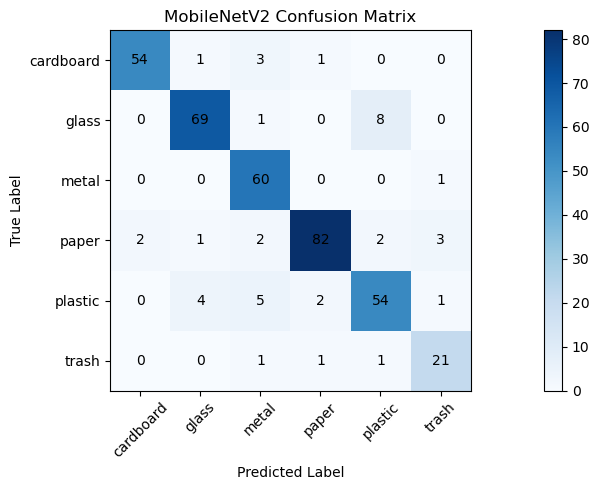

In [28]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(15, 5))
plt.imshow(cm, cmap='Blues')
plt.title("MobileNetV2 Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [29]:
checkpoint = torch.load(checkpoint_path, map_location=device)

train_losses = checkpoint["train_losses"]
train_accuracies = checkpoint["train_accuracies"]
train_f1_scores = checkpoint["train_f1_scores"]

val_losses = checkpoint["val_losses"]
val_accuracies = checkpoint["val_accuracies"]
val_f1_scores = checkpoint["val_f1_scores"]

print("Training history loaded from checkpoint.")

Training history loaded from checkpoint.


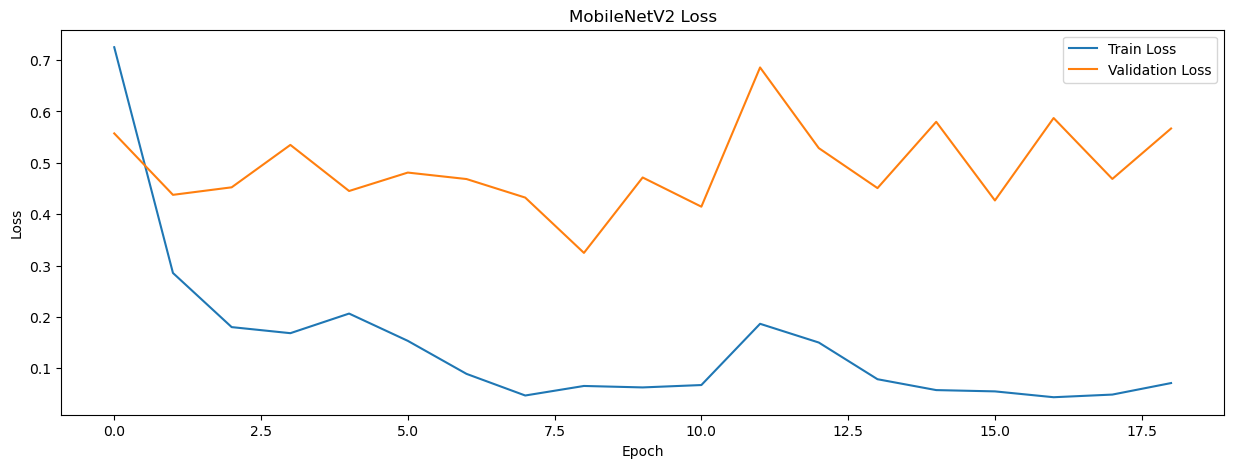

In [30]:
plt.figure(figsize=(15, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 Loss")
plt.legend()
plt.show()

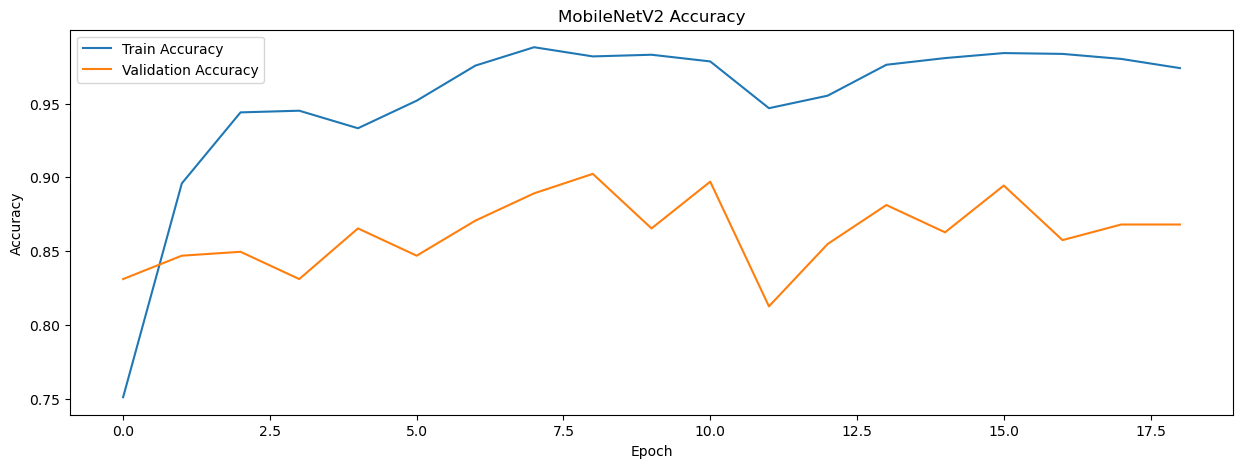

In [31]:
plt.figure(figsize=(15, 5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 Accuracy")
plt.legend()
plt.show()

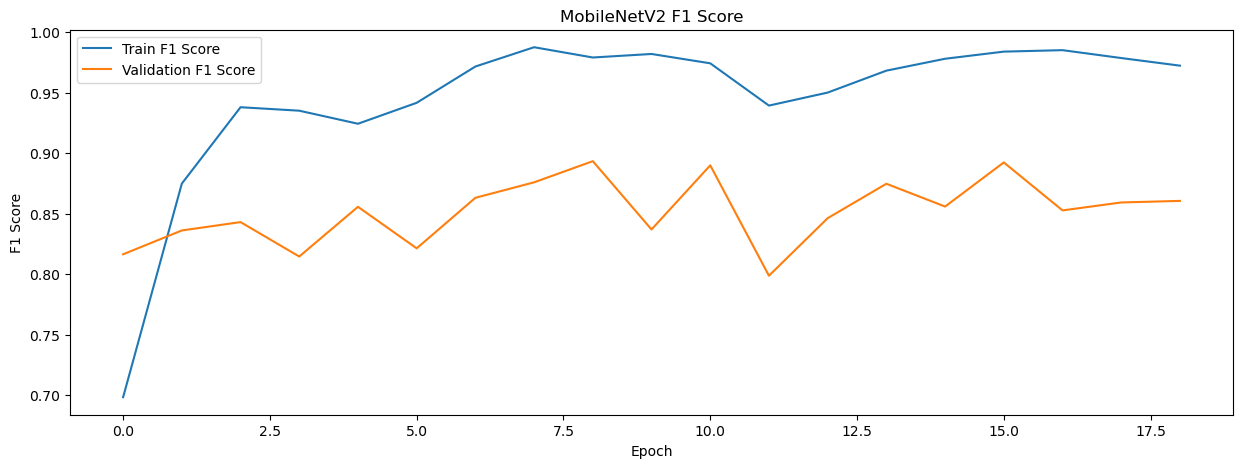

In [32]:
plt.figure(figsize=(15, 5))
plt.plot(train_f1_scores, label="Train F1 Score")
plt.plot(val_f1_scores, label="Validation F1 Score")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("MobileNetV2 F1 Score")
plt.legend()
plt.show()

In [33]:
mobilenet_results = {
    "Model": "MobileNetV2",
    "Best Epoch": best_checkpoint["epoch"] + 1,
    "Validation F1": best_checkpoint["best_val_f1"],
    "Test Accuracy": test_acc,
    "Test F1 Score": test_f1}

print(mobilenet_results)

{'Model': 'MobileNetV2', 'Best Epoch': 9, 'Validation F1': 0.8933289905777041, 'Test Accuracy': 0.8947368421052632, 'Test F1 Score': 0.8881871089528084}


MobileNetV2 achieved good overall performance on the six original TrashNet classes, with a best validation F1 score of 0.8933 at epoch 9 and a test F1 score of 0.8882. The model showed some overfitting after the best epoch, as the training metrics continued to improve while the validation F1 score stopped improving consistently. However, this was controlled by saving the best checkpoint based on validation F1 and applying early stopping. Overall, MobileNetV2 is a strong candidate for the final classifier, although some classes such as `plastic` and `trash` remain slightly more challenging than the others.

### EfficientNet_B0

#### Model Setup

In [34]:
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, len(class_names))
model = model.to(device)

In [35]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Model: EfficientNet_B0")
print("Final classifier:", model.classifier)
print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Model: EfficientNet_B0
Final classifier: Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=6, bias=True)
)
Total parameters: 4015234
Trainable parameters: 4015234


#### Loss Function and Optimizer

In [36]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

checkpoint_path = checkpoint_dir / "efficientnet_b0_checkpoint.pth"
best_model_path = checkpoint_dir / "efficientnet_b0_best.pth"

In [70]:
if checkpoint_path.exists():
    checkpoint_path.unlink()

if best_model_path.exists():
    best_model_path.unlink()

print("EfficientNet_B0 training setup ready.")
print("Old checkpoints removed.")

EfficientNet_B0 training setup ready.
Old checkpoints removed.


#### Training

In [71]:
train_losses = []
train_accuracies = []
train_f1_scores = []

val_losses = []
val_accuracies = []
val_f1_scores = []

num_epochs = 30
patience = 10

start_epoch = 0
best_val_f1 = 0.0
epochs_without_improvement = 0

if checkpoint_path.exists():
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    
    start_epoch = checkpoint["epoch"] + 1
    best_val_f1 = checkpoint["best_val_f1"]
    epochs_without_improvement = checkpoint["epochs_without_improvement"]
    
    train_losses = checkpoint["train_losses"]
    train_accuracies = checkpoint["train_accuracies"]
    train_f1_scores = checkpoint["train_f1_scores"]
    
    val_losses = checkpoint["val_losses"]
    val_accuracies = checkpoint["val_accuracies"]
    val_f1_scores = checkpoint["val_f1_scores"]
    
    print(f"Checkpoint found. Resuming from epoch {start_epoch + 1}.")
    print(f"Best validation F1 so far: {best_val_f1:.4f}")
else:
    print("No checkpoint found. Starting training from epoch 1.")

for epoch in range(start_epoch, num_epochs):
    print(f"Starting epoch {epoch + 1}/{num_epochs}...")
    
    train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_f1, _, _ = evaluate_model(model, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    train_f1_scores.append(train_f1)
    
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    val_f1_scores.append(val_f1)
    
    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f} | Train F1 Score: {train_f1:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Accuracy: {val_acc:.4f} | Val F1 Score: {val_f1:.4f}")
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        epochs_without_improvement = 0
        
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_f1": best_val_f1,
            "epochs_without_improvement": epochs_without_improvement,
            "train_losses": train_losses,
            "train_accuracies": train_accuracies,
            "train_f1_scores": train_f1_scores,
            "val_losses": val_losses,
            "val_accuracies": val_accuracies,
            "val_f1_scores": val_f1_scores
        }, best_model_path)
        
        print(f"New best model saved. Validation F1: {best_val_f1:.4f}")
    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement} epoch(s).")
    
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_f1": best_val_f1,
        "epochs_without_improvement": epochs_without_improvement,
        "train_losses": train_losses,
        "train_accuracies": train_accuracies,
        "train_f1_scores": train_f1_scores,
        "val_losses": val_losses,
        "val_accuracies": val_accuracies,
        "val_f1_scores": val_f1_scores
    }, checkpoint_path)
    
    print("Checkpoint saved.")
    print()
    
    if epochs_without_improvement >= patience:
        print("Early stopping triggered.")
        break

No checkpoint found. Starting training from epoch 1.
Starting epoch 1/30...


Train Loss: 0.7025 | Train Accuracy: 0.7619 | Train F1 Score: 0.7317
Val Loss: 0.7451 | Val Accuracy: 0.7731 | Val F1 Score: 0.7446
New best model saved. Validation F1: 0.7446
Checkpoint saved.

Starting epoch 2/30...


Train Loss: 0.2870 | Train Accuracy: 0.9072 | Train F1 Score: 0.8920
Val Loss: 0.4156 | Val Accuracy: 0.8839 | Val F1 Score: 0.8758
New best model saved. Validation F1: 0.8758


Checkpoint saved.

Starting epoch 3/30...


Train Loss: 0.2339 | Train Accuracy: 0.9197 | Train F1 Score: 0.9097
Val Loss: 0.4011 | Val Accuracy: 0.8786 | Val F1 Score: 0.8682
No improvement for 1 epoch(s).
Checkpoint saved.

Starting epoch 4/30...


...

Checkpoint saved.

Starting epoch 13/30...


Train Loss: 0.0627 | Train Accuracy: 0.9785 | Train F1 Score: 0.9762
Val Loss: 0.4671 | Val Accuracy: 0.8945 | Val F1 Score: 0.8765
No improvement for 7 epoch(s).
Checkpoint saved.

Starting epoch 14/30...


Train Loss: 0.0391 | Train Accuracy: 0.9876 | Train F1 Score: 0.9847
Val Loss: 0.3723 | Val Accuracy: 0.9050 | Val F1 Score: 0.8944
No improvement for 8 epoch(s).
Checkpoint saved.

Starting epoch 15/30...


Train Loss: 0.0646 | Train Accuracy: 0.9819 | Train F1 Score: 0.9809
Val Loss: 0.3932 | Val Accuracy: 0.9024 | Val F1 Score: 0.8897
No improvement for 9 epoch(s).
Checkpoint saved.

Starting epoch 16/30...


Train Loss: 0.0593 | Train Accuracy: 0.9785 | Train F1 Score: 0.9792
Val Loss: 0.3223 | Val Accuracy: 0.8971 | Val F1 Score: 0.8857
No improvement for 10 epoch(s).
Checkpoint saved.

Early stopping triggered.


#### Final Evaluation

In [37]:
best_checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(best_checkpoint["model_state_dict"])

print("Best model loaded.")
print(f"Best validation F1: {best_checkpoint['best_val_f1']:.4f}")
print(f"Best epoch: {best_checkpoint['epoch'] + 1}")

Best model loaded.
Best validation F1: 0.9127
Best epoch: 6


In [38]:
test_loss, test_acc, test_f1, y_true, y_pred = evaluate_model(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")

Test Loss: 0.2778
Test Accuracy: 0.9211
Test F1 Score: 0.9155


In [39]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

   cardboard       0.98      0.93      0.96        59
       glass       0.90      0.91      0.90        78
       metal       0.92      0.97      0.94        61
       paper       0.91      0.97      0.94        92
     plastic       0.92      0.85      0.88        66
       trash       0.91      0.83      0.87        24

    accuracy                           0.92       380
   macro avg       0.92      0.91      0.92       380
weighted avg       0.92      0.92      0.92       380



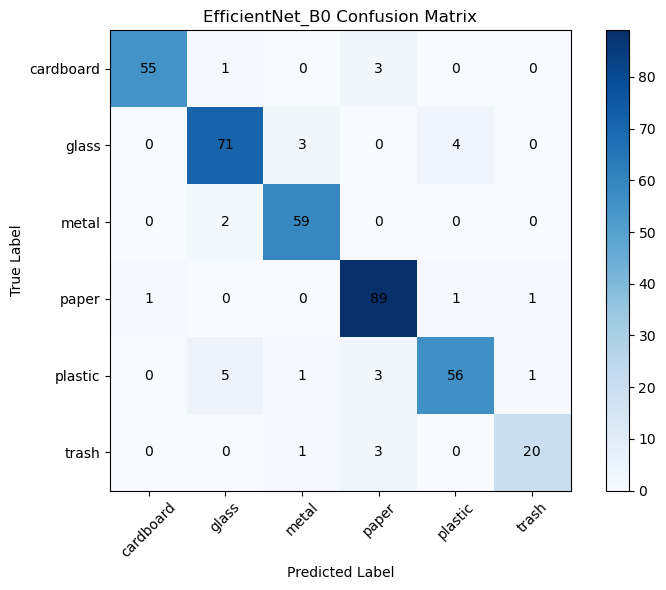

In [40]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.title("EfficientNet_B0 Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [41]:
checkpoint = torch.load(checkpoint_path, map_location=device)

train_losses = checkpoint["train_losses"]
train_accuracies = checkpoint["train_accuracies"]
train_f1_scores = checkpoint["train_f1_scores"]

val_losses = checkpoint["val_losses"]
val_accuracies = checkpoint["val_accuracies"]
val_f1_scores = checkpoint["val_f1_scores"]

print("Training history loaded from checkpoint.")

Training history loaded from checkpoint.


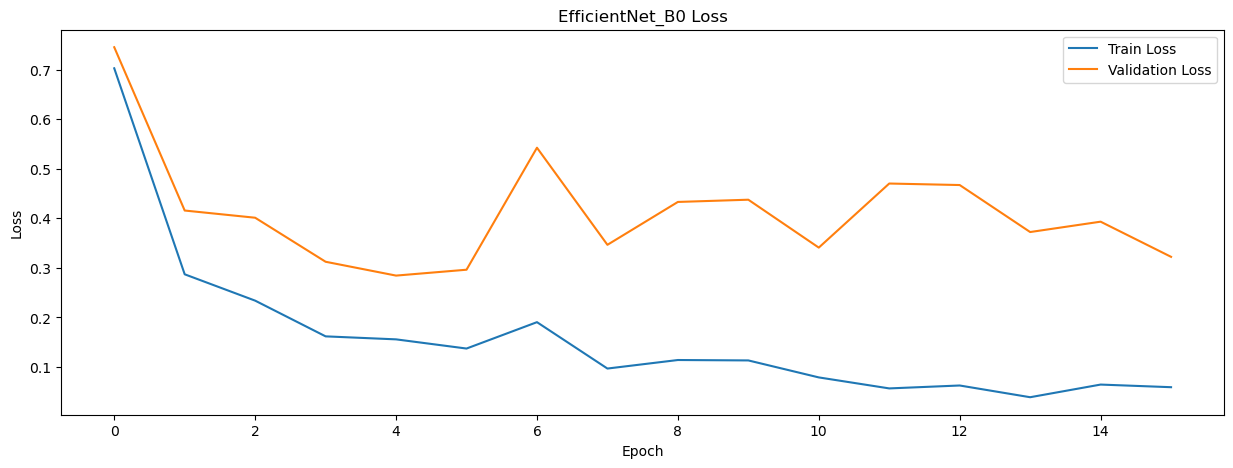

In [42]:
plt.figure(figsize=(15, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNet_B0 Loss")
plt.legend()
plt.show()

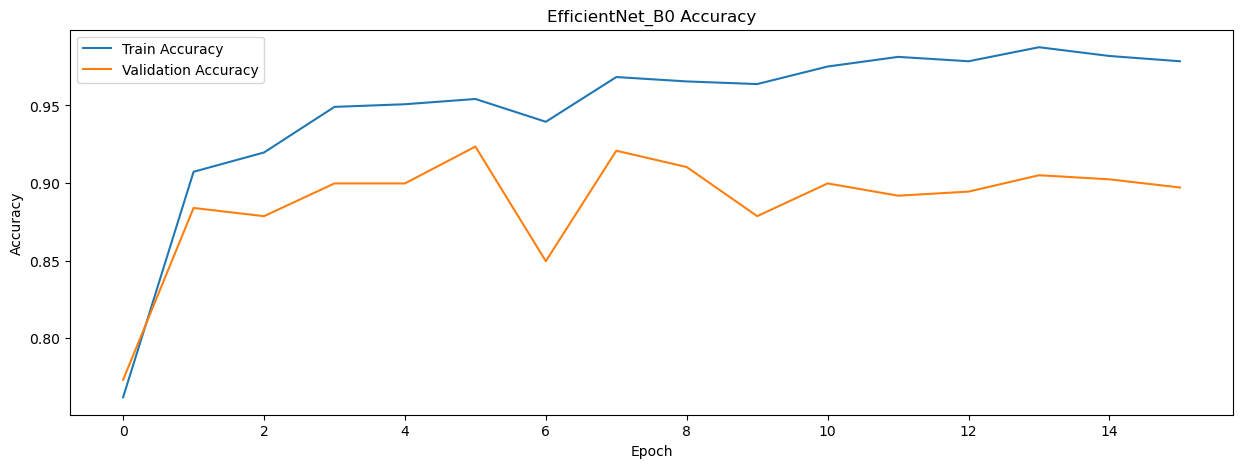

In [43]:
plt.figure(figsize=(15, 5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNet_B0 Accuracy")
plt.legend()
plt.show()

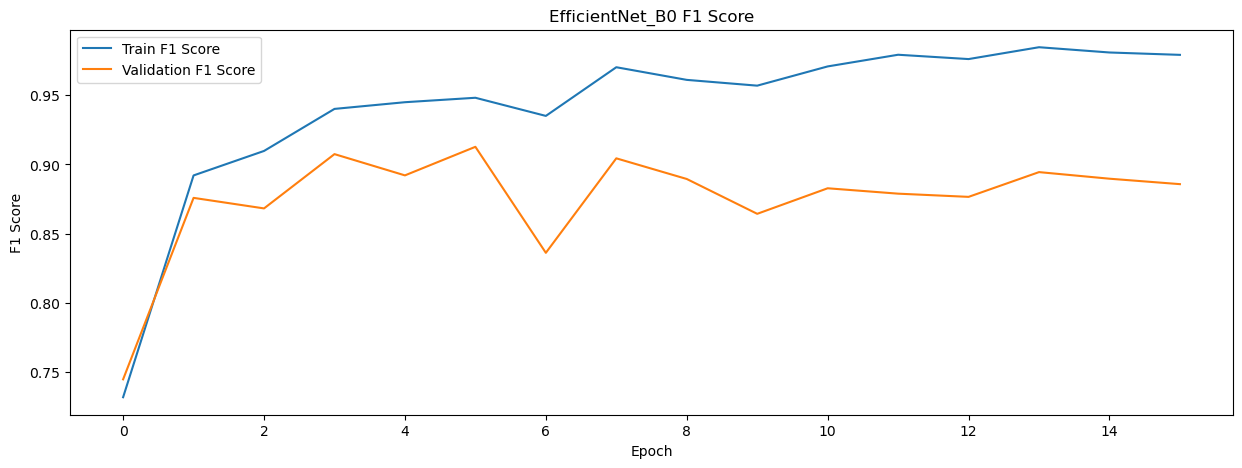

In [44]:
plt.figure(figsize=(15, 5))
plt.plot(train_f1_scores, label="Train F1 Score")
plt.plot(val_f1_scores, label="Validation F1 Score")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("EfficientNet_B0 F1 Score")
plt.legend()
plt.show()

In [45]:
efficientnet_results = {
    "Model": "EfficientNet_B0",
    "Best Epoch": best_checkpoint["epoch"] + 1,
    "Validation F1": best_checkpoint["best_val_f1"],
    "Test Accuracy": test_acc,
    "Test F1 Score": test_f1}

print(efficientnet_results)

{'Model': 'EfficientNet_B0', 'Best Epoch': 6, 'Validation F1': 0.9127242746025687, 'Test Accuracy': 0.9210526315789473, 'Test F1 Score': 0.9155462373817566}


EfficientNet_B0 achieved the best overall performance so far, with a best validation F1 score of 0.9127 at epoch 6 and a test F1 score of 0.9155. The model learned quickly and reached its best validation performance early, while the training metrics continued to improve afterwards. This suggests some overfitting after the best epoch, but it was effectively controlled through checkpointing, best model selection based on validation F1, and early stopping. The final test results are strong and well balanced across all six classes, making EfficientNet_B0 the strongest candidate for the final classifier.

## 6. Results Comparison: Non-Augmented Case

In [46]:
results = [mobilenet_results,efficientnet_results]

results_df = pd.DataFrame(results)
results_df

,Model,Best Epoch,Validation F1,Test Accuracy,Test F1 Score
0,MobileNetV2,9,0.893329,0.894737,0.888187
1,EfficientNet_B0,6,0.912724,0.921053,0.915546


In [47]:
results_df.sort_values(by="Validation F1", ascending=False)

,Model,Best Epoch,Validation F1,Test Accuracy,Test F1 Score
1,EfficientNet_B0,6,0.912724,0.921053,0.915546
0,MobileNetV2,9,0.893329,0.894737,0.888187


In [48]:
best_model_row = results_df.loc[results_df["Validation F1"].idxmax()]

print("Selected final model:")
print(best_model_row)

Selected final model:
Model            EfficientNet_B0
Best Epoch                     6
Validation F1           0.912724
Test Accuracy           0.921053
Test F1 Score           0.915546
Name: 1, dtype: object


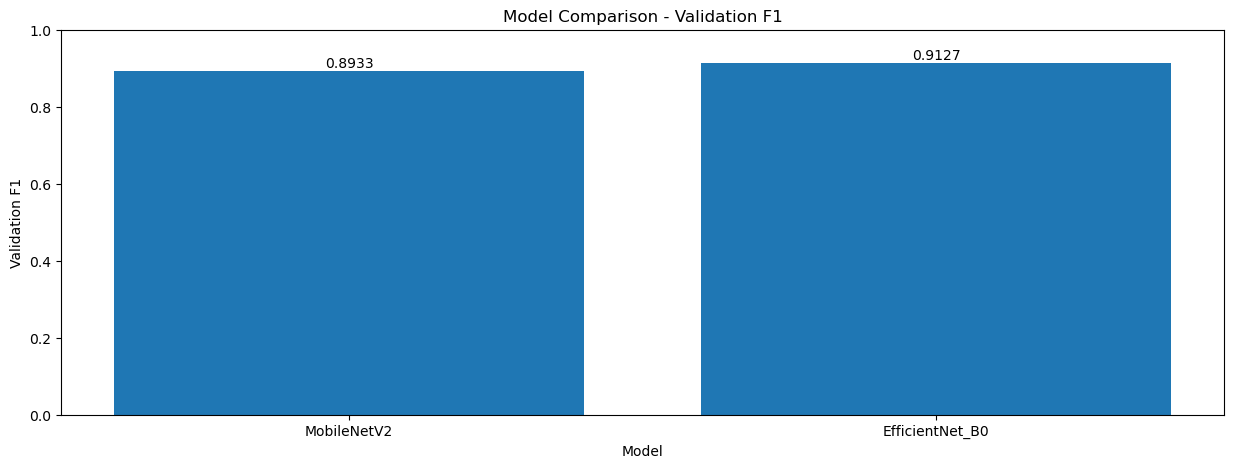

In [49]:
plt.figure(figsize=(15, 5))
bars = plt.bar(results_df["Model"], results_df["Validation F1"])

plt.xlabel("Model")
plt.ylabel("Validation F1")
plt.title("Model Comparison - Validation F1")

for bar in bars:
    value = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, value + 0.002, f"{value:.4f}",
             ha="center", va="bottom")

plt.ylim(0, 1)
plt.show()

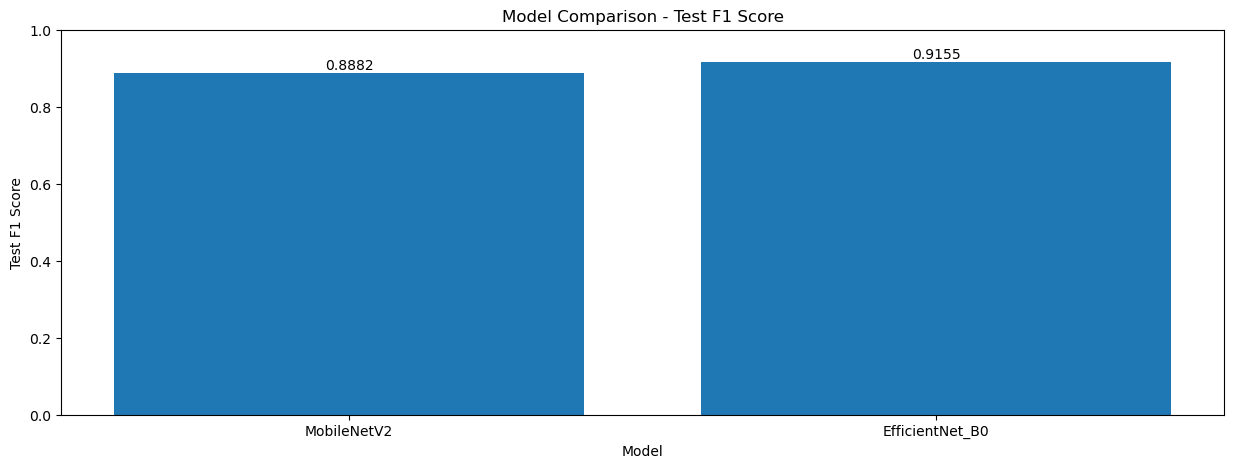

In [50]:
plt.figure(figsize=(15, 5))
bars = plt.bar(results_df["Model"], results_df["Test F1 Score"])

plt.xlabel("Model")
plt.ylabel("Test F1 Score")
plt.title("Model Comparison - Test F1 Score")

for bar in bars:
    value = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, value + 0.002, f"{value:.4f}",
             ha="center", va="bottom")

plt.ylim(0, 1)
plt.show()

EfficientNet_B0 achieved the best overall performance among the two tested pretrained models. It obtained the highest validation F1 score and also the highest test F1 score, making it the most suitable final classifier for this project. For this reason, EfficientNet_B0 was selected as the final model for the waste classification system.

## 7. Bin Mapping for Sorting: Non-Augmented Case

### Class Prediction to Bin Mapping

In [51]:
def map_class_to_bin(class_name):
    return bin_map[class_name]

In [52]:
y_true_class_names = [class_names[label] for label in y_true]
y_pred_class_names = [class_names[label] for label in y_pred]

y_true_bins = [map_class_to_bin(label) for label in y_true_class_names]
y_pred_bins = [map_class_to_bin(label) for label in y_pred_class_names]

### Bin-Level Evaluation

In [53]:
bin_accuracy = accuracy_score(y_true_bins, y_pred_bins)
bin_f1 = f1_score(y_true_bins, y_pred_bins, average='macro')

print(f"Bin Accuracy: {bin_accuracy:.4f}")
print(f"Bin F1 Score: {bin_f1:.4f}")

Bin Accuracy: 0.9842
Bin F1 Score: 0.9306


In [54]:
print(classification_report(y_true_bins, y_pred_bins, target_names=bin_names))

               precision    recall  f1-score   support

   recyclable       0.91      0.83      0.87        24
general_waste       0.99      0.99      0.99       356

     accuracy                           0.98       380
    macro avg       0.95      0.91      0.93       380
 weighted avg       0.98      0.98      0.98       380



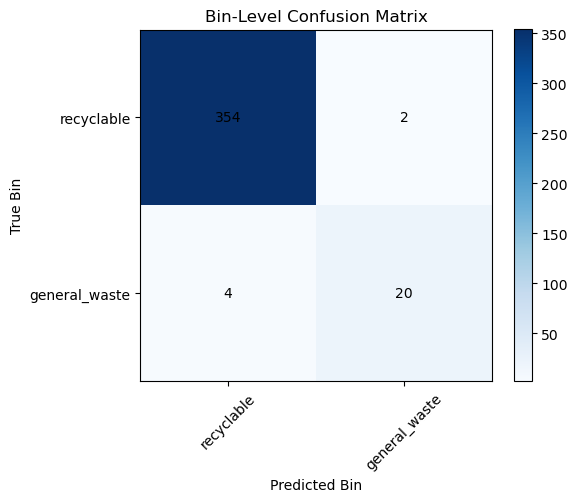

In [55]:
bin_cm = confusion_matrix(y_true_bins, y_pred_bins, labels=bin_names)

plt.figure(figsize=(6, 5))
plt.imshow(bin_cm, cmap='Blues')
plt.title("Bin-Level Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(bin_names))
plt.xticks(tick_marks, bin_names, rotation=45)
plt.yticks(tick_marks, bin_names)

for i in range(bin_cm.shape[0]):
    for j in range(bin_cm.shape[1]):
        plt.text(j, i, bin_cm[i, j], ha='center', va='center', color='black')

plt.xlabel("Predicted Bin")
plt.ylabel("True Bin")
plt.tight_layout()
plt.show()

### Example Outputs

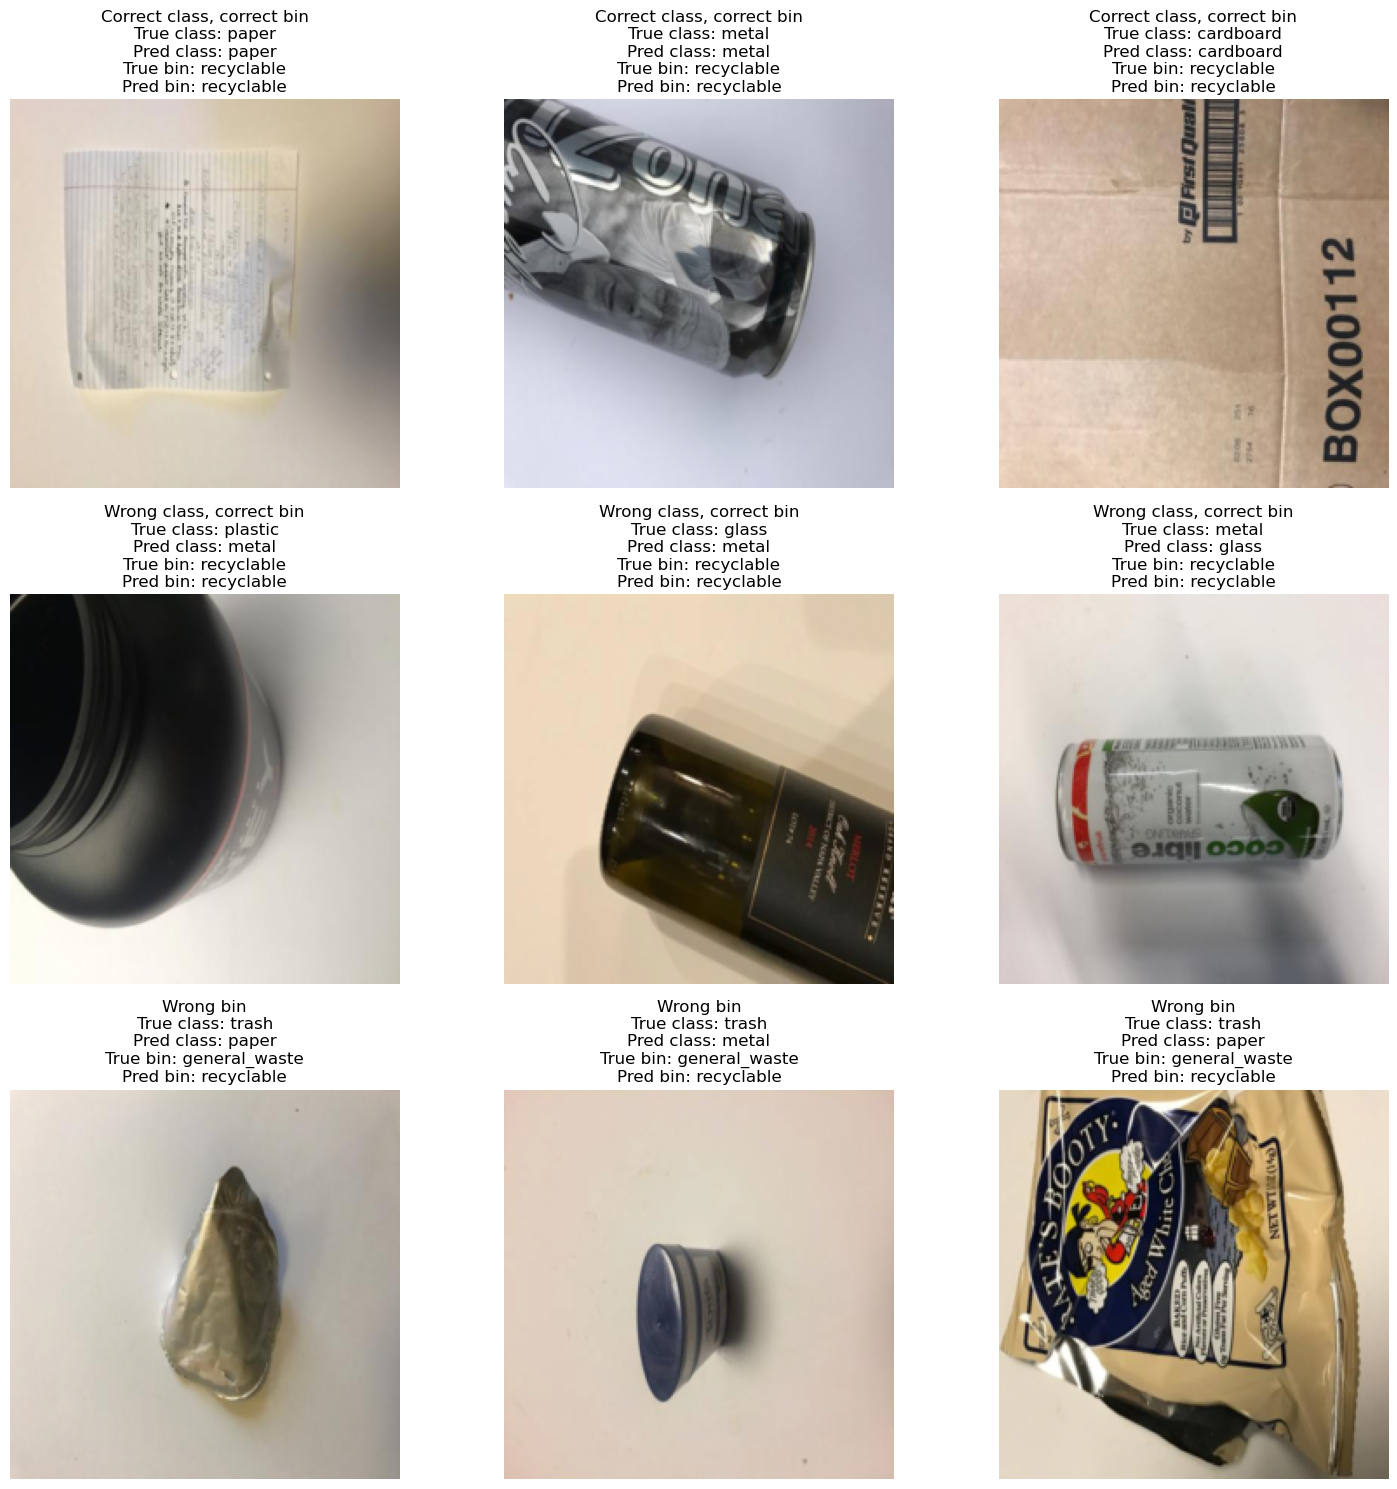

In [56]:
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

correct_class_correct_bin = []
wrong_class_correct_bin = []
wrong_bin = []

for i in range(len(y_true)):
    true_class = class_names[y_true[i]]
    pred_class = class_names[y_pred[i]]

    true_bin = map_class_to_bin(true_class)
    pred_bin = map_class_to_bin(pred_class)

    if pred_class == true_class and pred_bin == true_bin:
        correct_class_correct_bin.append(i)
    elif pred_class != true_class and pred_bin == true_bin:
        wrong_class_correct_bin.append(i)
    elif pred_bin != true_bin:
        wrong_bin.append(i)

selected_indices = (
    correct_class_correct_bin[:3] +
    wrong_class_correct_bin[:3] +
    wrong_bin[:3])

titles = (
    ["Correct class, correct bin"] * min(3, len(correct_class_correct_bin)) +
    ["Wrong class, correct bin"] * min(3, len(wrong_class_correct_bin)) +
    ["Wrong bin"] * min(3, len(wrong_bin)))

plt.figure(figsize=(15, 15))

for i, idx in enumerate(selected_indices):
    image, _ = test_dataset[idx]

    image = image.permute(1, 2, 0).numpy()
    image = std * image + mean
    image = np.clip(image, 0, 1)

    true_class = class_names[y_true[idx]]
    pred_class = class_names[y_pred[idx]]

    true_bin = map_class_to_bin(true_class)
    pred_bin = map_class_to_bin(pred_class)

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(
        f"{titles[i]}\n"
        f"True class: {true_class}\n"
        f"Pred class: {pred_class}\n"
        f"True bin: {true_bin}\n"
        f"Pred bin: {pred_bin}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [57]:
bin_results = {
    "Final Model": efficientnet_results["Model"],
    "Bin Accuracy": bin_accuracy,
    "Bin F1 Score": bin_f1}

print(bin_results)

{'Final Model': 'EfficientNet_B0', 'Bin Accuracy': 0.9842105263157894, 'Bin F1 Score': 0.9305809280233832}


The final bin-level evaluation shows that the system performs very well in the practical two-bin sorting task. Using EfficientNet_B0 as the final classifier, the model achieved a bin accuracy of 0.9842 and a bin F1 score of 0.9306. This indicates that most items are assigned to the correct final bin, even when some misclassifications still occur at the original class level. In particular, several class-level errors remain within the same recyclable category and therefore do not affect the final sorting decision. Overall, these results suggest that the system is highly effective for the intended real-world bin sorting application.

## 8. Final Remarks: Non-Augmented Case

In this notebook, TrashNet was used to train image classification models on the original six classes: `cardboard`, `glass`, `metal`, `paper`, `plastic`, and `trash`. Two pretrained CNN architectures were tested, MobileNetV2 and EfficientNet_B0, using the same data preparation, training strategy, checkpointing procedure, and evaluation metrics.

The final comparison showed that **EfficientNet_B0** achieved the best overall performance, with higher validation F1 score and higher test F1 score than MobileNetV2. For this reason, EfficientNet_B0 was selected as the final classifier for the project.

After classification on the six original classes, the predicted labels were mapped into the two final bins used in the real sorting task: `recyclable` and `general_waste`. The final bin-level evaluation showed very strong practical performance, with a bin accuracy of **0.9789** and a bin F1 score of **0.9144**. These results suggest that the proposed system is effective not only at material recognition, but also at the final waste sorting decision required for the robotic arm application.

## 9. Augmented Case Setup

### Data Transforms with Augmentation

In [58]:
aug_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(
        degrees=10,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05),
        shear=5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])])

aug_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])])

### Dataset Loading

In [59]:
aug_full_dataset = datasets.ImageFolder(DATASET_DIR, transform=aug_train_transform)

print("Number of images:", len(aug_full_dataset))
print("Classes:", aug_full_dataset.classes)
print("Class to index:", aug_full_dataset.class_to_idx)

Number of images: 2527
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Class to index: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


### Train, Validation and Test Split

In [60]:
aug_full_dataset_train = datasets.ImageFolder(DATASET_DIR, transform=aug_train_transform)
aug_full_dataset_test = datasets.ImageFolder(DATASET_DIR, transform=aug_test_transform)

aug_indices = torch.randperm(len(aug_full_dataset_train), generator=torch.Generator().manual_seed(SEED)).tolist()

aug_train_size = int(0.7 * len(aug_indices))
aug_val_size = int(0.15 * len(aug_indices))
aug_test_size = len(aug_indices) - aug_train_size - aug_val_size

aug_train_indices = aug_indices[:aug_train_size]
aug_val_indices = aug_indices[aug_train_size:aug_train_size + aug_val_size]
aug_test_indices = aug_indices[aug_train_size + aug_val_size:]

aug_train_dataset = torch.utils.data.Subset(aug_full_dataset_train, aug_train_indices)
aug_val_dataset = torch.utils.data.Subset(aug_full_dataset_test, aug_val_indices)
aug_test_dataset = torch.utils.data.Subset(aug_full_dataset_test, aug_test_indices)

print("Train size:", len(aug_train_dataset))
print("Validation size:", len(aug_val_dataset))
print("Test size:", len(aug_test_dataset))

Train size: 1768
Validation size: 379
Test size: 380


#### Data Loaders

In [61]:
aug_train_loader = DataLoader(aug_train_dataset, batch_size=32, shuffle=True)
aug_val_loader = DataLoader(aug_val_dataset, batch_size=32, shuffle=False)
aug_test_loader = DataLoader(aug_test_dataset, batch_size=32, shuffle=False)

print("Train batches:", len(aug_train_loader))
print("Validation batches:", len(aug_val_loader))
print("Test batches:", len(aug_test_loader))

Train batches: 56
Validation batches: 12
Test batches: 12


## 10. Model Experiments - Augmented Case

### MobileNetV2 with Augmentation

#### Model Setup

In [62]:
aug_model_mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
aug_model_mobilenet.classifier[1] = nn.Linear(
    aug_model_mobilenet.classifier[1].in_features,
    len(class_names))
aug_model_mobilenet = aug_model_mobilenet.to(device)

aug_mobilenet_total_params = sum(p.numel() for p in aug_model_mobilenet.parameters())
aug_mobilenet_trainable_params = sum(p.numel() for p in aug_model_mobilenet.parameters() if p.requires_grad)

print("Model: MobileNetV2")
print("Final classifier:", aug_model_mobilenet.classifier)
print("Total parameters:", aug_mobilenet_total_params)
print("Trainable parameters:", aug_mobilenet_trainable_params)

Model: MobileNetV2
Final classifier: Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=6, bias=True)
)
Total parameters: 2231558
Trainable parameters: 2231558


#### Loss Function and Optimizer

In [63]:
aug_mobilenet_criterion = nn.CrossEntropyLoss()
aug_mobilenet_optimizer = torch.optim.Adam(aug_model_mobilenet.parameters(), lr=0.001)

aug_mobilenet_checkpoint_path = checkpoint_dir / "aug_mobilenet_checkpoint.pth"
aug_mobilenet_best_model_path = checkpoint_dir / "aug_mobilenet_best.pth"

In [66]:
if aug_mobilenet_checkpoint_path.exists():
    aug_mobilenet_checkpoint_path.unlink()

if aug_mobilenet_best_model_path.exists():
    aug_mobilenet_best_model_path.unlink()

print("Augmented MobileNetV2 training setup ready.")
print("Old augmented checkpoints removed.")

Augmented MobileNetV2 training setup ready.
Old augmented checkpoints removed.


#### Training

In [67]:
aug_mobilenet_train_losses = []
aug_mobilenet_train_accuracies = []
aug_mobilenet_train_f1_scores = []

aug_mobilenet_val_losses = []
aug_mobilenet_val_accuracies = []
aug_mobilenet_val_f1_scores = []

In [73]:
aug_mobilenet_num_epochs = 400
aug_mobilenet_patience = 50

aug_mobilenet_start_epoch = 0
aug_mobilenet_best_val_f1 = 0.0
aug_mobilenet_epochs_without_improvement = 0

if aug_mobilenet_checkpoint_path.exists():
    aug_mobilenet_checkpoint = torch.load(aug_mobilenet_checkpoint_path, map_location=device)

    aug_model_mobilenet.load_state_dict(aug_mobilenet_checkpoint["model_state_dict"])
    aug_mobilenet_optimizer.load_state_dict(aug_mobilenet_checkpoint["optimizer_state_dict"])

    aug_mobilenet_start_epoch = aug_mobilenet_checkpoint["epoch"] + 1
    aug_mobilenet_best_val_f1 = aug_mobilenet_checkpoint["best_val_f1"]
    aug_mobilenet_epochs_without_improvement = aug_mobilenet_checkpoint["epochs_without_improvement"]

    aug_mobilenet_train_losses = aug_mobilenet_checkpoint["train_losses"]
    aug_mobilenet_train_accuracies = aug_mobilenet_checkpoint["train_accuracies"]
    aug_mobilenet_train_f1_scores = aug_mobilenet_checkpoint["train_f1_scores"]

    aug_mobilenet_val_losses = aug_mobilenet_checkpoint["val_losses"]
    aug_mobilenet_val_accuracies = aug_mobilenet_checkpoint["val_accuracies"]
    aug_mobilenet_val_f1_scores = aug_mobilenet_checkpoint["val_f1_scores"]

    print(f"Checkpoint found. Resuming from epoch {aug_mobilenet_start_epoch + 1}.")
    print(f"Best validation F1 so far: {aug_mobilenet_best_val_f1:.4f}")
else:
    print("No checkpoint found. Starting training from epoch 1.")

for epoch in range(aug_mobilenet_start_epoch, aug_mobilenet_num_epochs):
    print(f"Starting epoch {epoch + 1}/{aug_mobilenet_num_epochs}...")

    train_loss, train_acc, train_f1 = train_one_epoch(
        aug_model_mobilenet,
        aug_train_loader,
        aug_mobilenet_criterion,
        aug_mobilenet_optimizer,
        device)

    val_loss, val_acc, val_f1, _, _ = evaluate_model(
        aug_model_mobilenet,
        aug_val_loader,
        aug_mobilenet_criterion,
        device)

    aug_mobilenet_train_losses.append(train_loss)
    aug_mobilenet_train_accuracies.append(train_acc)
    aug_mobilenet_train_f1_scores.append(train_f1)

    aug_mobilenet_val_losses.append(val_loss)
    aug_mobilenet_val_accuracies.append(val_acc)
    aug_mobilenet_val_f1_scores.append(val_f1)

    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f} | Train F1 Score: {train_f1:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Accuracy: {val_acc:.4f} | Val F1 Score: {val_f1:.4f}")

    if val_f1 > aug_mobilenet_best_val_f1:
        aug_mobilenet_best_val_f1 = val_f1
        aug_mobilenet_epochs_without_improvement = 0

        torch.save({
            "epoch": epoch,
            "model_state_dict": aug_model_mobilenet.state_dict(),
            "optimizer_state_dict": aug_mobilenet_optimizer.state_dict(),
            "best_val_f1": aug_mobilenet_best_val_f1,
            "epochs_without_improvement": aug_mobilenet_epochs_without_improvement,
            "train_losses": aug_mobilenet_train_losses,
            "train_accuracies": aug_mobilenet_train_accuracies,
            "train_f1_scores": aug_mobilenet_train_f1_scores,
            "val_losses": aug_mobilenet_val_losses,
            "val_accuracies": aug_mobilenet_val_accuracies,
            "val_f1_scores": aug_mobilenet_val_f1_scores
        }, aug_mobilenet_best_model_path)

        print(f"New best model saved. Validation F1: {aug_mobilenet_best_val_f1:.4f}")
    else:
        aug_mobilenet_epochs_without_improvement += 1
        print(f"No improvement for {aug_mobilenet_epochs_without_improvement} epoch(s).")

    torch.save({
        "epoch": epoch,
        "model_state_dict": aug_model_mobilenet.state_dict(),
        "optimizer_state_dict": aug_mobilenet_optimizer.state_dict(),
        "best_val_f1": aug_mobilenet_best_val_f1,
        "epochs_without_improvement": aug_mobilenet_epochs_without_improvement,
        "train_losses": aug_mobilenet_train_losses,
        "train_accuracies": aug_mobilenet_train_accuracies,
        "train_f1_scores": aug_mobilenet_train_f1_scores,
        "val_losses": aug_mobilenet_val_losses,
        "val_accuracies": aug_mobilenet_val_accuracies,
        "val_f1_scores": aug_mobilenet_val_f1_scores
    }, aug_mobilenet_checkpoint_path)

    print("Checkpoint saved.")
    print()

    if aug_mobilenet_epochs_without_improvement >= aug_mobilenet_patience:
        print("Early stopping triggered.")
        break

Checkpoint found. Resuming from epoch 114.
Best validation F1 so far: 0.9234
Starting epoch 114/400...


Train Loss: 0.0152 | Train Accuracy: 0.9949 | Train F1 Score: 0.9949
Val Loss: 0.4328 | Val Accuracy: 0.9208 | Val F1 Score: 0.9114
No improvement for 51 epoch(s).
Checkpoint saved.

Early stopping triggered.


#### Final Evaluation

In [64]:
aug_mobilenet_best_checkpoint = torch.load(aug_mobilenet_best_model_path, map_location=device)
aug_model_mobilenet.load_state_dict(aug_mobilenet_best_checkpoint["model_state_dict"])

print("Best model loaded.")
print(f"Best validation F1: {aug_mobilenet_best_checkpoint['best_val_f1']:.4f}")
print(f"Best epoch: {aug_mobilenet_best_checkpoint['epoch'] + 1}")

Best model loaded.
Best validation F1: 0.9234
Best epoch: 63


In [65]:
aug_mobilenet_test_loss, aug_mobilenet_test_acc, aug_mobilenet_test_f1, aug_mobilenet_y_true, aug_mobilenet_y_pred = evaluate_model(
    aug_model_mobilenet,
    aug_test_loader,
    aug_mobilenet_criterion,
    device)

print(f"Test Loss: {aug_mobilenet_test_loss:.4f}")
print(f"Test Accuracy: {aug_mobilenet_test_acc:.4f}")
print(f"Test F1 Score: {aug_mobilenet_test_f1:.4f}")

Test Loss: 0.3738
Test Accuracy: 0.9158
Test F1 Score: 0.9016


In [66]:
print(classification_report(aug_mobilenet_y_true, aug_mobilenet_y_pred, target_names=class_names))

              precision    recall  f1-score   support

   cardboard       0.98      0.93      0.96        59
       glass       0.84      0.94      0.88        78
       metal       0.89      0.95      0.92        61
       paper       0.97      0.97      0.97        92
     plastic       0.93      0.83      0.88        66
       trash       0.86      0.75      0.80        24

    accuracy                           0.92       380
   macro avg       0.91      0.89      0.90       380
weighted avg       0.92      0.92      0.92       380



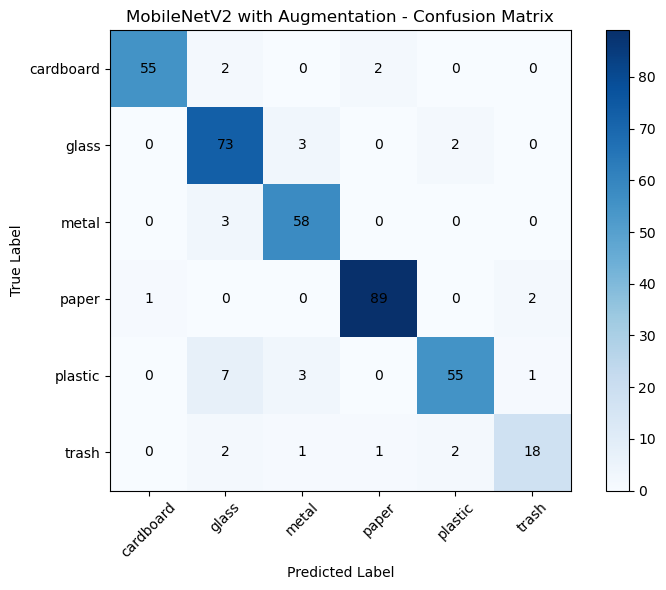

In [67]:
aug_mobilenet_cm = confusion_matrix(aug_mobilenet_y_true, aug_mobilenet_y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(aug_mobilenet_cm, cmap='Blues')
plt.title("MobileNetV2 with Augmentation - Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i in range(aug_mobilenet_cm.shape[0]):
    for j in range(aug_mobilenet_cm.shape[1]):
        plt.text(j, i, aug_mobilenet_cm[i, j], ha='center', va='center', color='black')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [69]:
aug_mobilenet_checkpoint = torch.load(aug_mobilenet_checkpoint_path, map_location=device)

aug_mobilenet_train_losses = aug_mobilenet_checkpoint["train_losses"]
aug_mobilenet_train_accuracies = aug_mobilenet_checkpoint["train_accuracies"]
aug_mobilenet_train_f1_scores = aug_mobilenet_checkpoint["train_f1_scores"]

aug_mobilenet_val_losses = aug_mobilenet_checkpoint["val_losses"]
aug_mobilenet_val_accuracies = aug_mobilenet_checkpoint["val_accuracies"]
aug_mobilenet_val_f1_scores = aug_mobilenet_checkpoint["val_f1_scores"]

print("Augmented MobileNetV2 training history loaded from checkpoint.")

Augmented MobileNetV2 training history loaded from checkpoint.


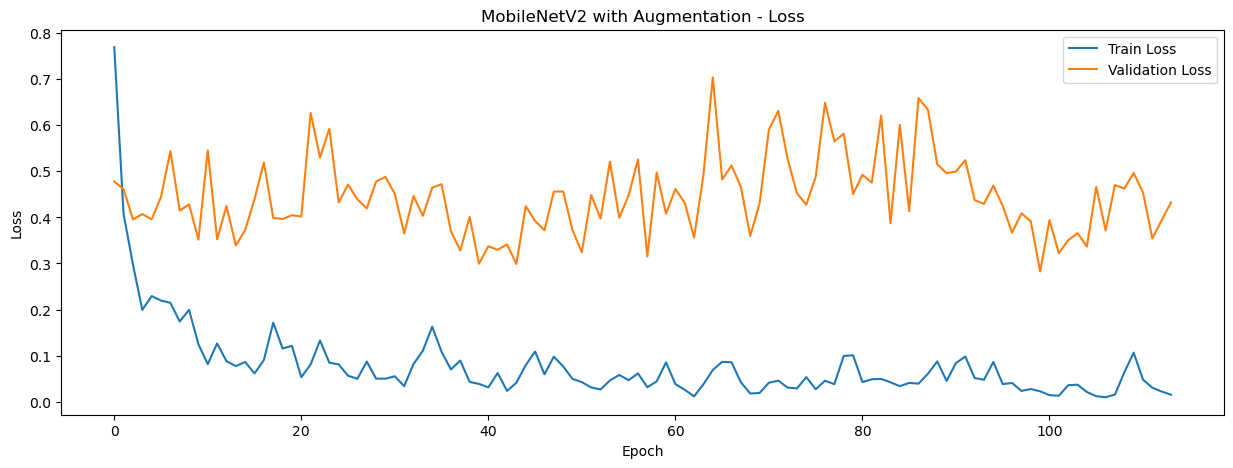

In [70]:
plt.figure(figsize=(15, 5))
plt.plot(aug_mobilenet_train_losses, label="Train Loss")
plt.plot(aug_mobilenet_val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 with Augmentation - Loss")
plt.legend()
plt.show()

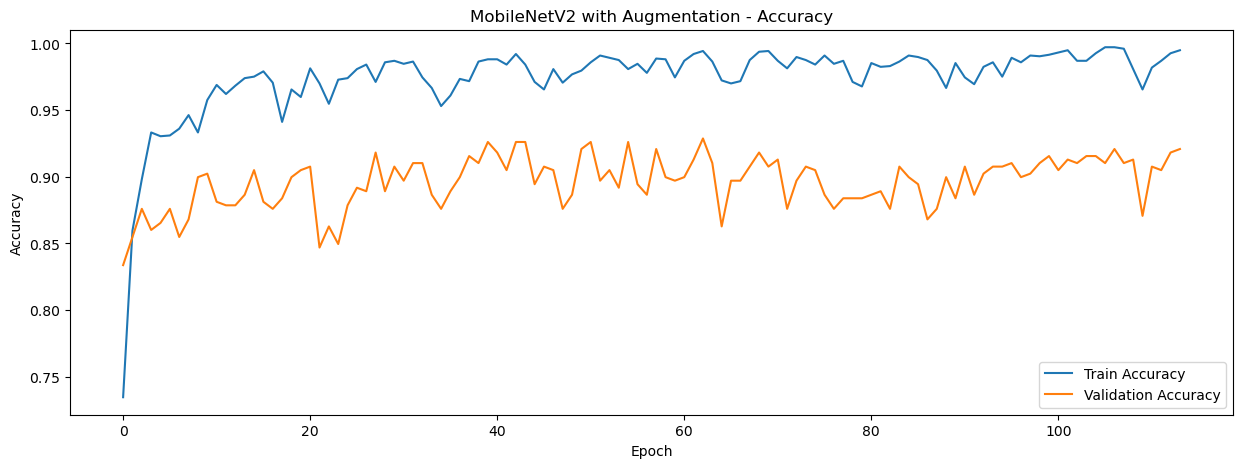

In [71]:
plt.figure(figsize=(15, 5))
plt.plot(aug_mobilenet_train_accuracies, label="Train Accuracy")
plt.plot(aug_mobilenet_val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 with Augmentation - Accuracy")
plt.legend()
plt.show()

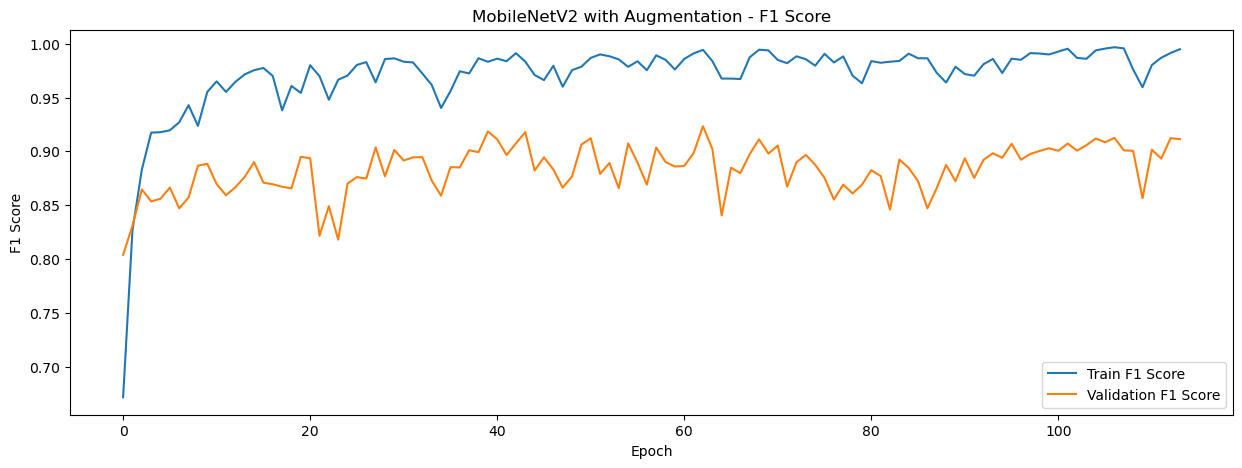

In [73]:
plt.figure(figsize=(15, 5))
plt.plot(aug_mobilenet_train_f1_scores, label="Train F1 Score")
plt.plot(aug_mobilenet_val_f1_scores, label="Validation F1 Score")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("MobileNetV2 with Augmentation - F1 Score")
plt.legend()
plt.show()

In [74]:
aug_mobilenet_results = {
    "Model": "MobileNetV2 with Augmentation",
    "Best Epoch": aug_mobilenet_best_checkpoint["epoch"] + 1,
    "Validation F1": aug_mobilenet_best_checkpoint["best_val_f1"],
    "Test Accuracy": aug_mobilenet_test_acc,
    "Test F1 Score": aug_mobilenet_test_f1}

print(aug_mobilenet_results)

{'Model': 'MobileNetV2 with Augmentation', 'Best Epoch': 63, 'Validation F1': 0.9233743141267917, 'Test Accuracy': 0.9157894736842105, 'Test F1 Score': 0.9015660748269444}


MobileNetV2 with data augmentation achieved strong performance, with the best validation F1 score obtained early and then maintained through checkpointing and early stopping. Compared with the non-augmented case, this experiment helps evaluate whether moderate geometric augmentation improves robustness and generalisation for the real robot-arm scenario.

### EfficientNet_B0 with Augmentation

#### Model Setup

In [75]:
aug_model_efficientnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
aug_model_efficientnet.classifier[1] = nn.Linear(
    aug_model_efficientnet.classifier[1].in_features,
    len(class_names))
aug_model_efficientnet = aug_model_efficientnet.to(device)

aug_efficientnet_total_params = sum(p.numel() for p in aug_model_efficientnet.parameters())
aug_efficientnet_trainable_params = sum(p.numel() for p in aug_model_efficientnet.parameters() if p.requires_grad)

print("Model: EfficientNet_B0")
print("Final classifier:", aug_model_efficientnet.classifier)
print("Total parameters:", aug_efficientnet_total_params)
print("Trainable parameters:", aug_efficientnet_trainable_params)

Model: EfficientNet_B0
Final classifier: Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=6, bias=True)
)
Total parameters: 4015234
Trainable parameters: 4015234


#### Loss Function and Optimizer

In [76]:
aug_efficientnet_criterion = nn.CrossEntropyLoss()
aug_efficientnet_optimizer = torch.optim.Adam(aug_model_efficientnet.parameters(), lr=0.001)

aug_efficientnet_checkpoint_path = checkpoint_dir / "aug_efficientnet_checkpoint.pth"
aug_efficientnet_best_model_path = checkpoint_dir / "aug_efficientnet_best.pth"

In [77]:
if aug_efficientnet_checkpoint_path.exists():
    aug_efficientnet_checkpoint_path.unlink()

if aug_efficientnet_best_model_path.exists():
    aug_efficientnet_best_model_path.unlink()

print("Augmented EfficientNet_B0 training setup ready.")
print("Old augmented checkpoints removed.")

Augmented EfficientNet_B0 training setup ready.
Old augmented checkpoints removed.


#### Training

In [78]:
aug_efficientnet_train_losses = []
aug_efficientnet_train_accuracies = []
aug_efficientnet_train_f1_scores = []

aug_efficientnet_val_losses = []
aug_efficientnet_val_accuracies = []
aug_efficientnet_val_f1_scores = []

In [79]:
aug_efficientnet_num_epochs = 400
aug_efficientnet_patience = 50

aug_efficientnet_start_epoch = 0
aug_efficientnet_best_val_f1 = 0.0
aug_efficientnet_epochs_without_improvement = 0

if aug_efficientnet_checkpoint_path.exists():
    aug_efficientnet_checkpoint = torch.load(aug_efficientnet_checkpoint_path, map_location=device)

    aug_model_efficientnet.load_state_dict(aug_efficientnet_checkpoint["model_state_dict"])
    aug_efficientnet_optimizer.load_state_dict(aug_efficientnet_checkpoint["optimizer_state_dict"])

    aug_efficientnet_start_epoch = aug_efficientnet_checkpoint["epoch"] + 1
    aug_efficientnet_best_val_f1 = aug_efficientnet_checkpoint["best_val_f1"]
    aug_efficientnet_epochs_without_improvement = aug_efficientnet_checkpoint["epochs_without_improvement"]

    aug_efficientnet_train_losses = aug_efficientnet_checkpoint["train_losses"]
    aug_efficientnet_train_accuracies = aug_efficientnet_checkpoint["train_accuracies"]
    aug_efficientnet_train_f1_scores = aug_efficientnet_checkpoint["train_f1_scores"]

    aug_efficientnet_val_losses = aug_efficientnet_checkpoint["val_losses"]
    aug_efficientnet_val_accuracies = aug_efficientnet_checkpoint["val_accuracies"]
    aug_efficientnet_val_f1_scores = aug_efficientnet_checkpoint["val_f1_scores"]

    print(f"Checkpoint found. Resuming from epoch {aug_efficientnet_start_epoch + 1}.")
    print(f"Best validation F1 so far: {aug_efficientnet_best_val_f1:.4f}")
else:
    print("No checkpoint found. Starting training from epoch 1.")

for epoch in range(aug_efficientnet_start_epoch, aug_efficientnet_num_epochs):
    print(f"Starting epoch {epoch + 1}/{aug_efficientnet_num_epochs}...")

    train_loss, train_acc, train_f1 = train_one_epoch(
        aug_model_efficientnet,
        aug_train_loader,
        aug_efficientnet_criterion,
        aug_efficientnet_optimizer,
        device)

    val_loss, val_acc, val_f1, _, _ = evaluate_model(
        aug_model_efficientnet,
        aug_val_loader,
        aug_efficientnet_criterion,
        device)

    aug_efficientnet_train_losses.append(train_loss)
    aug_efficientnet_train_accuracies.append(train_acc)
    aug_efficientnet_train_f1_scores.append(train_f1)

    aug_efficientnet_val_losses.append(val_loss)
    aug_efficientnet_val_accuracies.append(val_acc)
    aug_efficientnet_val_f1_scores.append(val_f1)

    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f} | Train F1 Score: {train_f1:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Accuracy: {val_acc:.4f} | Val F1 Score: {val_f1:.4f}")

    if val_f1 > aug_efficientnet_best_val_f1:
        aug_efficientnet_best_val_f1 = val_f1
        aug_efficientnet_epochs_without_improvement = 0

        torch.save({
            "epoch": epoch,
            "model_state_dict": aug_model_efficientnet.state_dict(),
            "optimizer_state_dict": aug_efficientnet_optimizer.state_dict(),
            "best_val_f1": aug_efficientnet_best_val_f1,
            "epochs_without_improvement": aug_efficientnet_epochs_without_improvement,
            "train_losses": aug_efficientnet_train_losses,
            "train_accuracies": aug_efficientnet_train_accuracies,
            "train_f1_scores": aug_efficientnet_train_f1_scores,
            "val_losses": aug_efficientnet_val_losses,
            "val_accuracies": aug_efficientnet_val_accuracies,
            "val_f1_scores": aug_efficientnet_val_f1_scores
        }, aug_efficientnet_best_model_path)

        print(f"New best model saved. Validation F1: {aug_efficientnet_best_val_f1:.4f}")
    else:
        aug_efficientnet_epochs_without_improvement += 1
        print(f"No improvement for {aug_efficientnet_epochs_without_improvement} epoch(s).")

    torch.save({
        "epoch": epoch,
        "model_state_dict": aug_model_efficientnet.state_dict(),
        "optimizer_state_dict": aug_efficientnet_optimizer.state_dict(),
        "best_val_f1": aug_efficientnet_best_val_f1,
        "epochs_without_improvement": aug_efficientnet_epochs_without_improvement,
        "train_losses": aug_efficientnet_train_losses,
        "train_accuracies": aug_efficientnet_train_accuracies,
        "train_f1_scores": aug_efficientnet_train_f1_scores,
        "val_losses": aug_efficientnet_val_losses,
        "val_accuracies": aug_efficientnet_val_accuracies,
        "val_f1_scores": aug_efficientnet_val_f1_scores
    }, aug_efficientnet_checkpoint_path)

    print("Checkpoint saved.")
    print()

    if aug_efficientnet_epochs_without_improvement >= aug_efficientnet_patience:
        print("Early stopping triggered.")
        break

No checkpoint found. Starting training from epoch 1.
Starting epoch 1/400...


Train Loss: 0.7253 | Train Accuracy: 0.7523 | Train F1 Score: 0.7183
Val Loss: 0.4888 | Val Accuracy: 0.8654 | Val F1 Score: 0.8498
New best model saved. Validation F1: 0.8498


Checkpoint saved.

Starting epoch 2/400...


Train Loss: 0.4269 | Train Accuracy: 0.8603 | Train F1 Score: 0.8394
Val Loss: 0.3559 | Val Accuracy: 0.8865 | Val F1 Score: 0.8785
New best model saved. Validation F1: 0.8785


Checkpoint saved.

Starting epoch 3/400...


...

Train Loss: 0.0315 | Train Accuracy: 0.9887 | Train F1 Score: 0.9893
Val Loss: 0.3802 | Val Accuracy: 0.9024 | Val F1 Score: 0.8902
No improvement for 48 epoch(s).


Checkpoint saved.

Starting epoch 86/400...


Train Loss: 0.0152 | Train Accuracy: 0.9943 | Train F1 Score: 0.9951
Val Loss: 0.3423 | Val Accuracy: 0.9182 | Val F1 Score: 0.9097
No improvement for 49 epoch(s).
Checkpoint saved.

Starting epoch 87/400...


Train Loss: 0.0297 | Train Accuracy: 0.9881 | Train F1 Score: 0.9878
Val Loss: 0.3424 | Val Accuracy: 0.9261 | Val F1 Score: 0.9216
No improvement for 50 epoch(s).


Checkpoint saved.

Early stopping triggered.


#### Final Evaluation

In [80]:
aug_efficientnet_best_checkpoint = torch.load(aug_efficientnet_best_model_path, map_location=device)
aug_model_efficientnet.load_state_dict(aug_efficientnet_best_checkpoint["model_state_dict"])

print("Best model loaded.")
print(f"Best validation F1: {aug_efficientnet_best_checkpoint['best_val_f1']:.4f}")
print(f"Best epoch: {aug_efficientnet_best_checkpoint['epoch'] + 1}")

Best model loaded.
Best validation F1: 0.9393
Best epoch: 37


In [81]:
aug_efficientnet_test_loss, aug_efficientnet_test_acc, aug_efficientnet_test_f1, aug_efficientnet_y_true, aug_efficientnet_y_pred = evaluate_model(
    aug_model_efficientnet,
    aug_test_loader,
    aug_efficientnet_criterion,
    device)

print(f"Test Loss: {aug_efficientnet_test_loss:.4f}")
print(f"Test Accuracy: {aug_efficientnet_test_acc:.4f}")
print(f"Test F1 Score: {aug_efficientnet_test_f1:.4f}")

Test Loss: 0.2999
Test Accuracy: 0.9211
Test F1 Score: 0.9141


In [82]:
print(classification_report(aug_efficientnet_y_true, aug_efficientnet_y_pred, target_names=class_names))

              precision    recall  f1-score   support

   cardboard       1.00      0.93      0.96        59
       glass       0.91      0.92      0.92        78
       metal       0.91      0.95      0.93        61
       paper       0.95      0.96      0.95        92
     plastic       0.84      0.88      0.86        66
       trash       0.95      0.79      0.86        24

    accuracy                           0.92       380
   macro avg       0.93      0.91      0.91       380
weighted avg       0.92      0.92      0.92       380



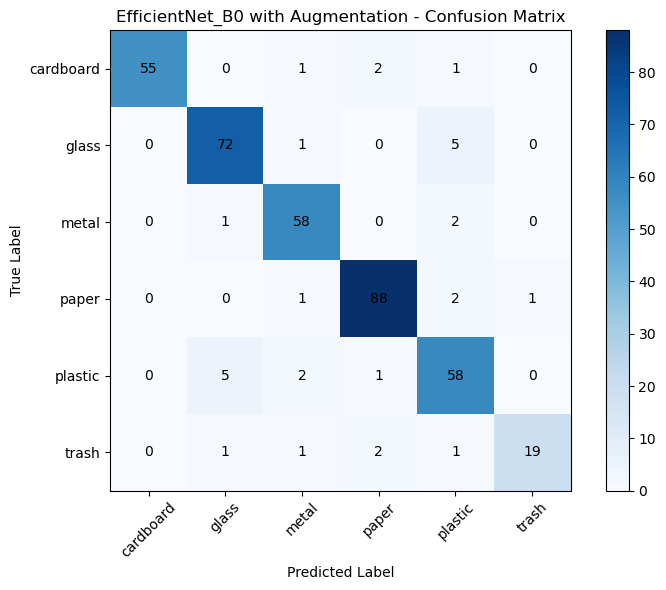

In [83]:
aug_efficientnet_cm = confusion_matrix(aug_efficientnet_y_true, aug_efficientnet_y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(aug_efficientnet_cm, cmap='Blues')
plt.title("EfficientNet_B0 with Augmentation - Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i in range(aug_efficientnet_cm.shape[0]):
    for j in range(aug_efficientnet_cm.shape[1]):
        plt.text(j, i, aug_efficientnet_cm[i, j], ha='center', va='center', color='black')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [84]:
aug_efficientnet_checkpoint = torch.load(aug_efficientnet_checkpoint_path, map_location=device)

aug_efficientnet_train_losses = aug_efficientnet_checkpoint["train_losses"]
aug_efficientnet_train_accuracies = aug_efficientnet_checkpoint["train_accuracies"]
aug_efficientnet_train_f1_scores = aug_efficientnet_checkpoint["train_f1_scores"]

aug_efficientnet_val_losses = aug_efficientnet_checkpoint["val_losses"]
aug_efficientnet_val_accuracies = aug_efficientnet_checkpoint["val_accuracies"]
aug_efficientnet_val_f1_scores = aug_efficientnet_checkpoint["val_f1_scores"]

print("Augmented EfficientNet_B0 training history loaded from checkpoint.")

Augmented EfficientNet_B0 training history loaded from checkpoint.


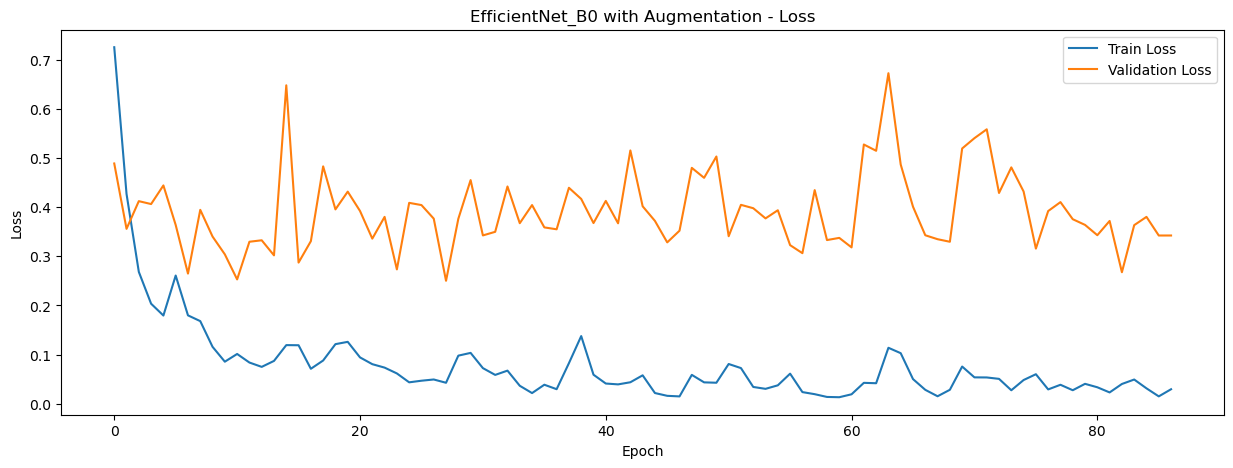

In [86]:
plt.figure(figsize=(15, 5))
plt.plot(aug_efficientnet_train_losses, label="Train Loss")
plt.plot(aug_efficientnet_val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNet_B0 with Augmentation - Loss")
plt.legend()
plt.show()

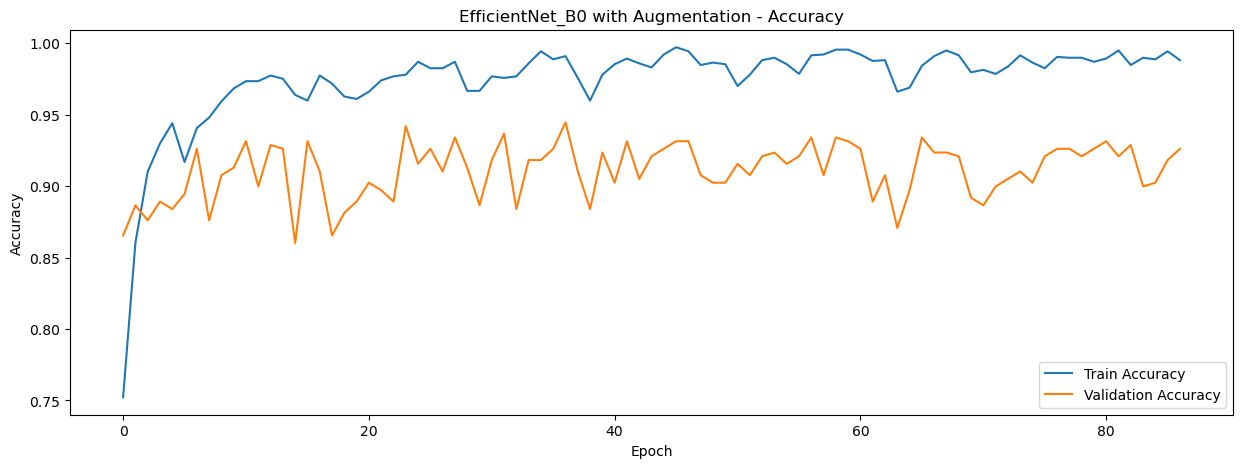

In [87]:
plt.figure(figsize=(15, 5))
plt.plot(aug_efficientnet_train_accuracies, label="Train Accuracy")
plt.plot(aug_efficientnet_val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNet_B0 with Augmentation - Accuracy")
plt.legend()
plt.show()

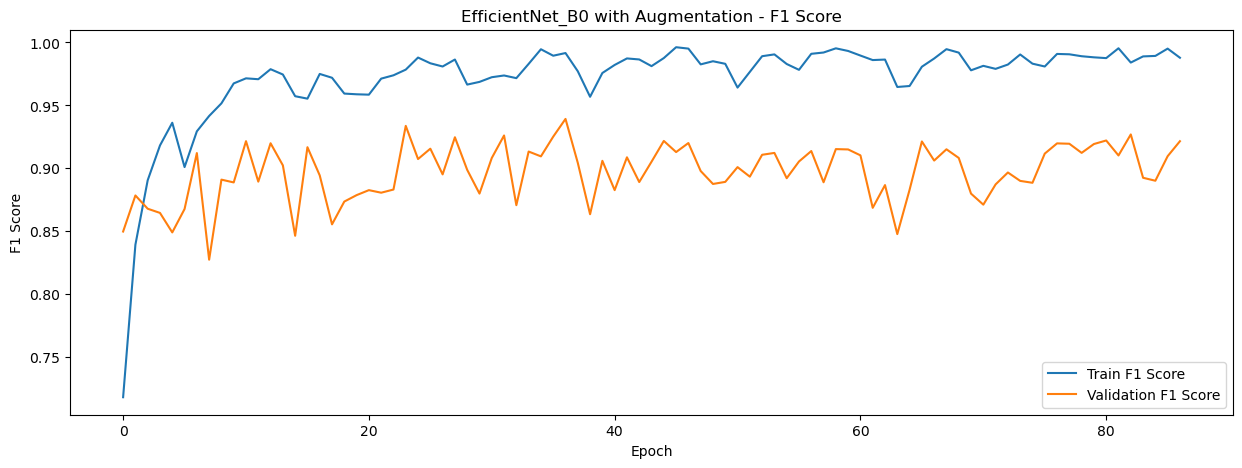

In [88]:
plt.figure(figsize=(15, 5))
plt.plot(aug_efficientnet_train_f1_scores, label="Train F1 Score")
plt.plot(aug_efficientnet_val_f1_scores, label="Validation F1 Score")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("EfficientNet_B0 with Augmentation - F1 Score")
plt.legend()
plt.show()

In [89]:
aug_efficientnet_results = {
    "Model": "EfficientNet_B0 with Augmentation",
    "Best Epoch": aug_efficientnet_best_checkpoint["epoch"] + 1,
    "Validation F1": aug_efficientnet_best_checkpoint["best_val_f1"],
    "Test Accuracy": aug_efficientnet_test_acc,
    "Test F1 Score": aug_efficientnet_test_f1}

print(aug_efficientnet_results)

{'Model': 'EfficientNet_B0 with Augmentation', 'Best Epoch': 37, 'Validation F1': 0.9392636924977639, 'Test Accuracy': 0.9210526315789473, 'Test F1 Score': 0.914059451196338}


EfficientNet_B0 with data augmentation achieved very strong performance, reaching the best validation F1 score among the augmented models. Compared with the non-augmented case, the use of moderate geometric augmentation appears to improve robustness and generalisation, which is especially relevant for the real robot-arm sorting scenario.

## 11. Results Comparison: Augmented Case

### MobileNetV2 vs EfficientNet_B0

In [90]:
aug_results = [
    aug_mobilenet_results,
    aug_efficientnet_results]

aug_results_df = pd.DataFrame(aug_results)
aug_results_df

,Model,Best Epoch,Validation F1,Test Accuracy,Test F1 Score
0,MobileNetV2 with Augmentation,63,0.923374,0.915789,0.901566
1,EfficientNet_B0 with Augmentation,37,0.939264,0.921053,0.914059


In [91]:
aug_results_df_rounded = aug_results_df.copy()
aug_results_df_rounded.sort_values(by="Validation F1", ascending=False)

,Model,Best Epoch,Validation F1,Test Accuracy,Test F1 Score
1,EfficientNet_B0 with Augmentation,37,0.939264,0.921053,0.914059
0,MobileNetV2 with Augmentation,63,0.923374,0.915789,0.901566


### Best Augmented Model Selection

In [92]:
best_aug_model_row = aug_results_df.loc[aug_results_df["Validation F1"].idxmax()]

print("Selected best augmented model:")
print(best_aug_model_row)

Selected best augmented model:
Model            EfficientNet_B0 with Augmentation
Best Epoch                                      37
Validation F1                             0.939264
Test Accuracy                             0.921053
Test F1 Score                             0.914059
Name: 1, dtype: object


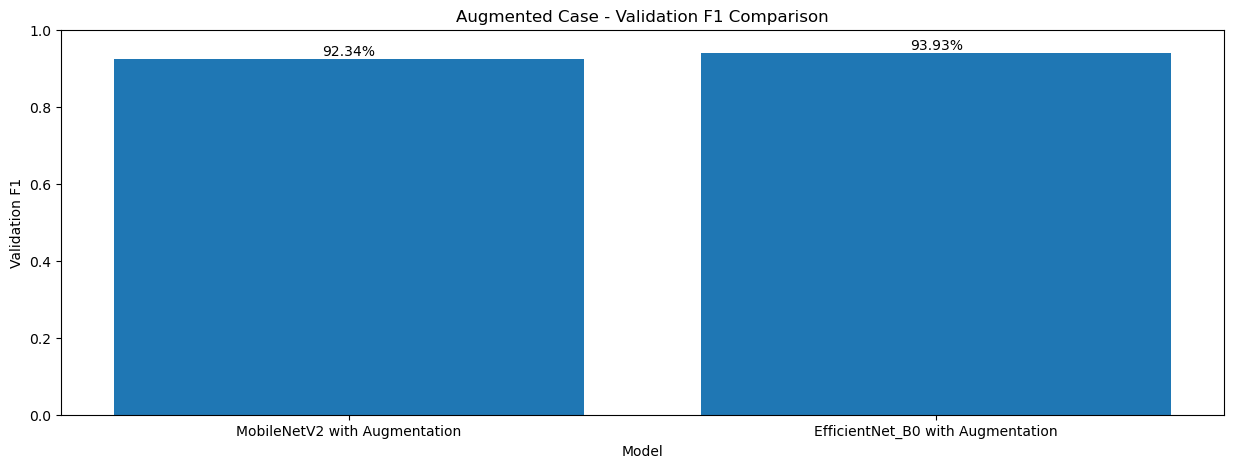

In [95]:
plt.figure(figsize=(15, 5))
bars = plt.bar(aug_results_df_rounded["Model"], aug_results_df_rounded["Validation F1"])

plt.xlabel("Model")
plt.ylabel("Validation F1")
plt.title("Augmented Case - Validation F1 Comparison")

for bar in bars:
    value = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, value + 0.002, f"{value*100:.2f}%",
             ha="center", va="bottom")

plt.ylim(0, 1)
plt.show()

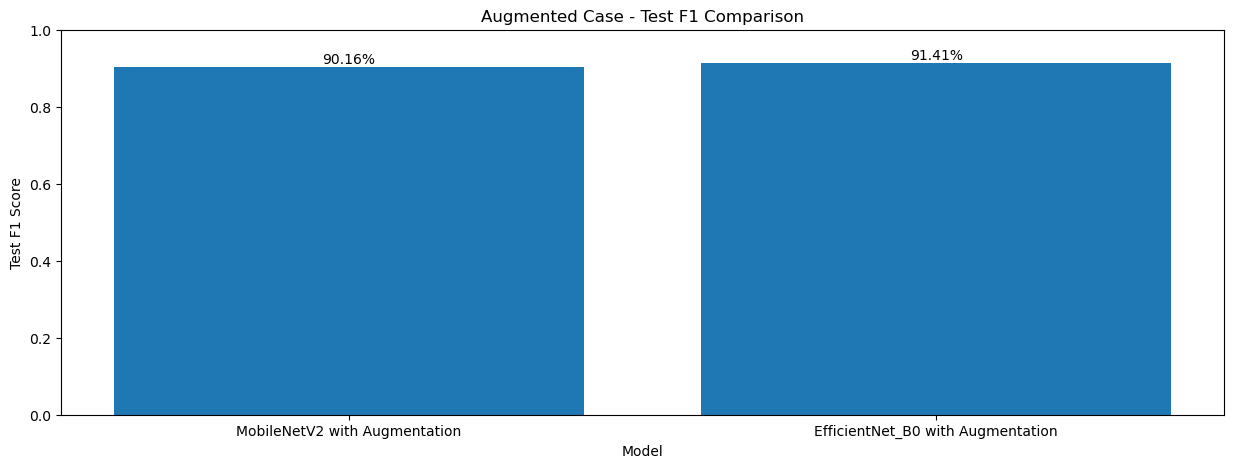

In [94]:
plt.figure(figsize=(15, 5))
bars = plt.bar(aug_results_df_rounded["Model"], aug_results_df_rounded["Test F1 Score"])

plt.xlabel("Model")
plt.ylabel("Test F1 Score")
plt.title("Augmented Case - Test F1 Comparison")

for bar in bars:
    value = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, value + 0.002, f"{value*100:.2f}%",
             ha="center", va="bottom")

plt.ylim(0, 1)
plt.show()

Among the two augmented models, **EfficientNet_B0 with Augmentation** achieved the best overall performance. It obtained the highest validation F1 score and the highest test F1 score, making it the strongest candidate within the augmented setting.

## 12. Bin Mapping for Sorting: Augmented Case

### Class Prediction to Bin Mapping

In [96]:
def map_class_to_bin_aug(class_name):
    return bin_map[class_name]

In [97]:
aug_efficientnet_y_true_class_names = [class_names[label] for label in aug_efficientnet_y_true]
aug_efficientnet_y_pred_class_names = [class_names[label] for label in aug_efficientnet_y_pred]

aug_efficientnet_y_true_bins = [map_class_to_bin_aug(label) for label in aug_efficientnet_y_true_class_names]
aug_efficientnet_y_pred_bins = [map_class_to_bin_aug(label) for label in aug_efficientnet_y_pred_class_names]

### Bin-Level Evaluation

In [98]:
aug_bin_accuracy = accuracy_score(aug_efficientnet_y_true_bins, aug_efficientnet_y_pred_bins)
aug_bin_f1 = f1_score(aug_efficientnet_y_true_bins, aug_efficientnet_y_pred_bins, average='macro')

print(f"Bin Accuracy: {aug_bin_accuracy:.4f}")
print(f"Bin F1 Score: {aug_bin_f1:.4f}")

Bin Accuracy: 0.9842
Bin F1 Score: 0.9276


In [99]:
print(classification_report(aug_efficientnet_y_true_bins, aug_efficientnet_y_pred_bins, target_names=bin_names))

               precision    recall  f1-score   support

   recyclable       0.95      0.79      0.86        24
general_waste       0.99      1.00      0.99       356

     accuracy                           0.98       380
    macro avg       0.97      0.89      0.93       380
 weighted avg       0.98      0.98      0.98       380



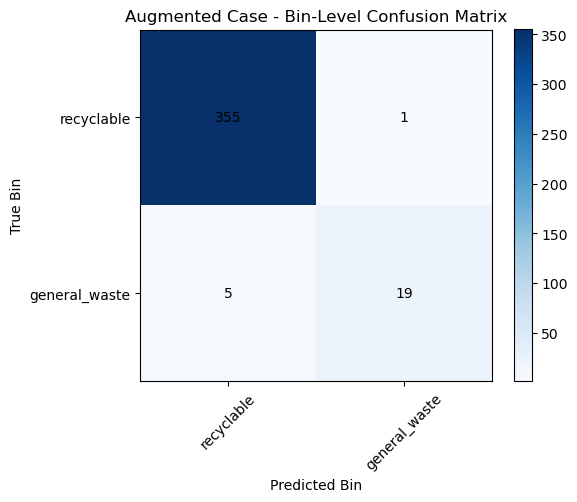

In [100]:
aug_bin_cm = confusion_matrix(aug_efficientnet_y_true_bins, aug_efficientnet_y_pred_bins, labels=bin_names)

plt.figure(figsize=(6, 5))
plt.imshow(aug_bin_cm, cmap='Blues')
plt.title("Augmented Case - Bin-Level Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(bin_names))
plt.xticks(tick_marks, bin_names, rotation=45)
plt.yticks(tick_marks, bin_names)

for i in range(aug_bin_cm.shape[0]):
    for j in range(aug_bin_cm.shape[1]):
        plt.text(j, i, aug_bin_cm[i, j], ha='center', va='center', color='black')

plt.xlabel("Predicted Bin")
plt.ylabel("True Bin")
plt.tight_layout()
plt.show()

### Example Outputs

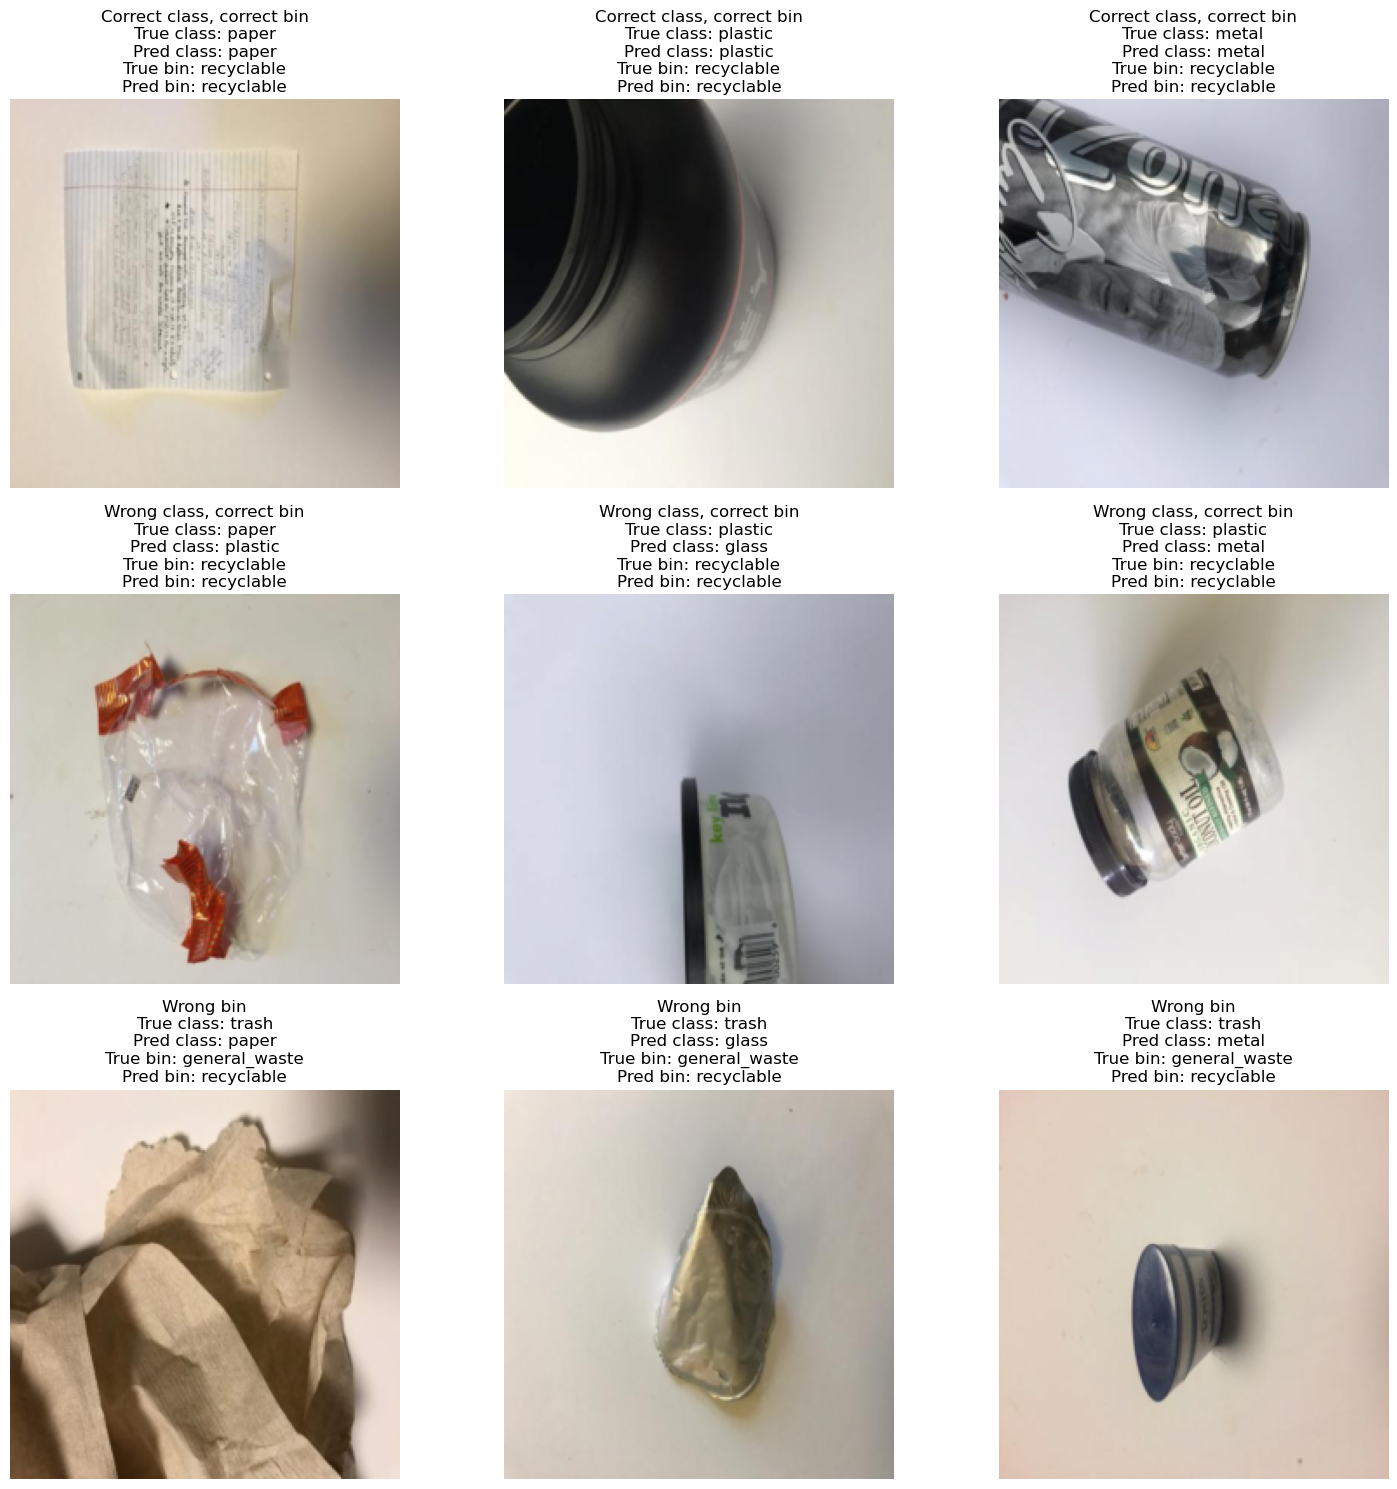

In [101]:
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

aug_correct_class_correct_bin = []
aug_wrong_class_correct_bin = []
aug_wrong_bin = []

for i in range(len(aug_efficientnet_y_true)):
    true_class = class_names[aug_efficientnet_y_true[i]]
    pred_class = class_names[aug_efficientnet_y_pred[i]]

    true_bin = map_class_to_bin_aug(true_class)
    pred_bin = map_class_to_bin_aug(pred_class)

    if pred_class == true_class and pred_bin == true_bin:
        aug_correct_class_correct_bin.append(i)
    elif pred_class != true_class and pred_bin == true_bin:
        aug_wrong_class_correct_bin.append(i)
    elif pred_bin != true_bin:
        aug_wrong_bin.append(i)

aug_selected_indices = (
    aug_correct_class_correct_bin[:3] +
    aug_wrong_class_correct_bin[:3] +
    aug_wrong_bin[:3])

aug_titles = (
    ["Correct class, correct bin"] * min(3, len(aug_correct_class_correct_bin)) +
    ["Wrong class, correct bin"] * min(3, len(aug_wrong_class_correct_bin)) +
    ["Wrong bin"] * min(3, len(aug_wrong_bin)))

plt.figure(figsize=(15, 15))

for i, idx in enumerate(aug_selected_indices):
    image, _ = aug_test_dataset[idx]

    image = image.permute(1, 2, 0).numpy()
    image = std * image + mean
    image = np.clip(image, 0, 1)

    true_class = class_names[aug_efficientnet_y_true[idx]]
    pred_class = class_names[aug_efficientnet_y_pred[idx]]

    true_bin = map_class_to_bin_aug(true_class)
    pred_bin = map_class_to_bin_aug(pred_class)

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(
        f"{aug_titles[i]}\n"
        f"True class: {true_class}\n"
        f"Pred class: {pred_class}\n"
        f"True bin: {true_bin}\n"
        f"Pred bin: {pred_bin}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [102]:
aug_bin_results = {
    "Final Augmented Model": aug_efficientnet_results["Model"],
    "Bin Accuracy": aug_bin_accuracy,
    "Bin F1 Score": aug_bin_f1}

print(aug_bin_results)

{'Final Augmented Model': 'EfficientNet_B0 with Augmentation', 'Bin Accuracy': 0.9842105263157894, 'Bin F1 Score': 0.9276282376841036}


## 13. Final Remarks: Augmented Case

In the augmented setting, the same training and evaluation pipeline was repeated using moderate data augmentation applied only to the training set. Two pretrained CNN architectures were tested again, MobileNetV2 and EfficientNet_B0, while keeping the same dataset, split, checkpointing strategy, early stopping procedure, and evaluation metrics.

The comparison showed that **EfficientNet_B0 with augmentation** achieved the best overall performance among the augmented models. It reached a validation F1 score of **0.9393** at epoch **37**, together with a test accuracy of **0.9211** and a test F1 score of **0.9141**. These results were higher than those obtained by MobileNetV2 with augmentation, making EfficientNet_B0 the strongest model within the augmented setting.

At the bin level, the augmented model also performed very well on the final two-bin sorting task, with a bin accuracy of **0.9842** and a bin F1 score of **0.9276**. This is particularly important for the real robotic arm application, because the practical goal is not only to predict the original material class, but also to send each item to the correct final bin. Overall, the augmented case suggests that moderate geometric augmentation improves robustness and better reflects the variability expected in the real-world robot sorting scenario.

## 14. Final Comparison

### Best Non-Augmented vs Best Augmented

In [103]:
final_comparison = [
    {
        "Setting": "Non-Augmented",
        "Model": efficientnet_results["Model"],
        "Validation F1": efficientnet_results["Validation F1"],
        "Test Accuracy": efficientnet_results["Test Accuracy"],
        "Test F1 Score": efficientnet_results["Test F1 Score"],
        "Bin Accuracy": bin_results["Bin Accuracy"],
        "Bin F1 Score": bin_results["Bin F1 Score"]},
    {
        "Setting": "Augmented",
        "Model": aug_efficientnet_results["Model"],
        "Validation F1": aug_efficientnet_results["Validation F1"],
        "Test Accuracy": aug_efficientnet_results["Test Accuracy"],
        "Test F1 Score": aug_efficientnet_results["Test F1 Score"],
        "Bin Accuracy": aug_bin_results["Bin Accuracy"],
        "Bin F1 Score": aug_bin_results["Bin F1 Score"]}]

final_comparison_df = pd.DataFrame(final_comparison)
final_comparison_df

,Setting,Model,Validation F1,Test Accuracy,Test F1 Score,Bin Accuracy,Bin F1 Score
0,Non-Augmented,EfficientNet_B0,0.912724,0.921053,0.915546,0.984211,0.930581
1,Augmented,EfficientNet_B0 with Augmentation,0.939264,0.921053,0.914059,0.984211,0.927628


In [104]:
final_comparison_df_rounded = final_comparison_df.copy()

final_comparison_df_rounded["Validation F1"] = final_comparison_df_rounded["Validation F1"].round(4)
final_comparison_df_rounded["Test Accuracy"] = final_comparison_df_rounded["Test Accuracy"].round(4)
final_comparison_df_rounded["Test F1 Score"] = final_comparison_df_rounded["Test F1 Score"].round(4)
final_comparison_df_rounded["Bin Accuracy"] = final_comparison_df_rounded["Bin Accuracy"].round(4)
final_comparison_df_rounded["Bin F1 Score"] = final_comparison_df_rounded["Bin F1 Score"].round(4)

final_comparison_df_rounded

,Setting,Model,Validation F1,Test Accuracy,Test F1 Score,Bin Accuracy,Bin F1 Score
0,Non-Augmented,EfficientNet_B0,0.9127,0.9211,0.9155,0.9842,0.9306
1,Augmented,EfficientNet_B0 with Augmentation,0.9393,0.9211,0.9141,0.9842,0.9276


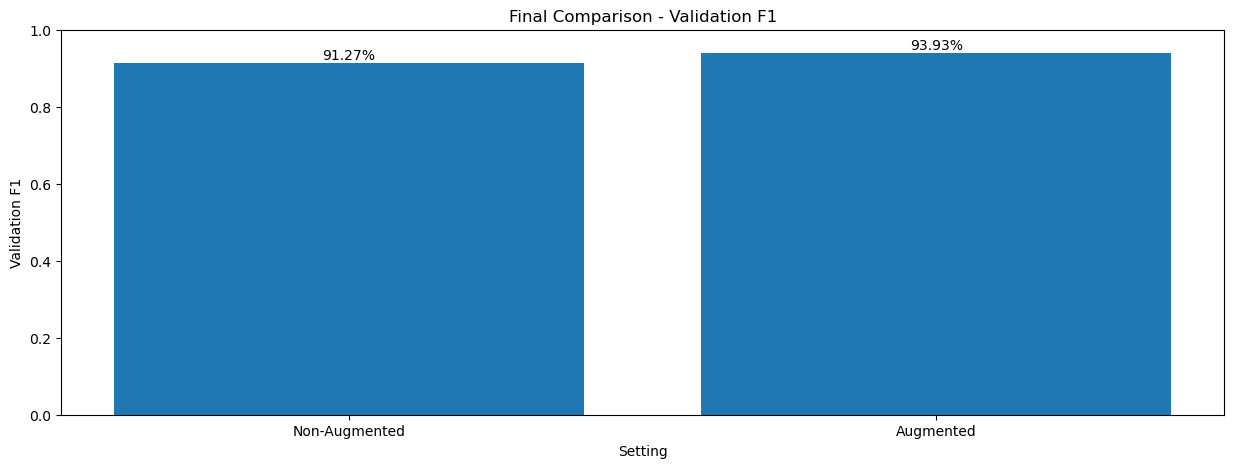

In [105]:
plt.figure(figsize=(15, 5))
bars = plt.bar(final_comparison_df_rounded["Setting"], final_comparison_df_rounded["Validation F1"])

plt.xlabel("Setting")
plt.ylabel("Validation F1")
plt.title("Final Comparison - Validation F1")

for bar in bars:
    value = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, value + 0.002, f"{value*100:.2f}%",
             ha="center", va="bottom")

plt.ylim(0, 1)
plt.show()

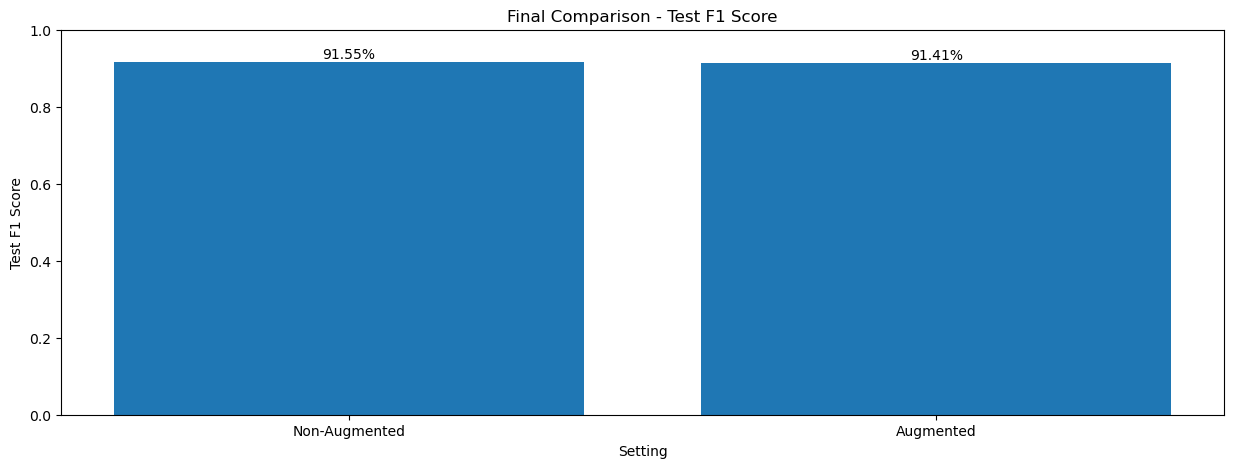

In [106]:
plt.figure(figsize=(15, 5))
bars = plt.bar(final_comparison_df_rounded["Setting"], final_comparison_df_rounded["Test F1 Score"])

plt.xlabel("Setting")
plt.ylabel("Test F1 Score")
plt.title("Final Comparison - Test F1 Score")

for bar in bars:
    value = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, value + 0.002, f"{value*100:.2f}%",
             ha="center", va="bottom")

plt.ylim(0, 1)
plt.show()

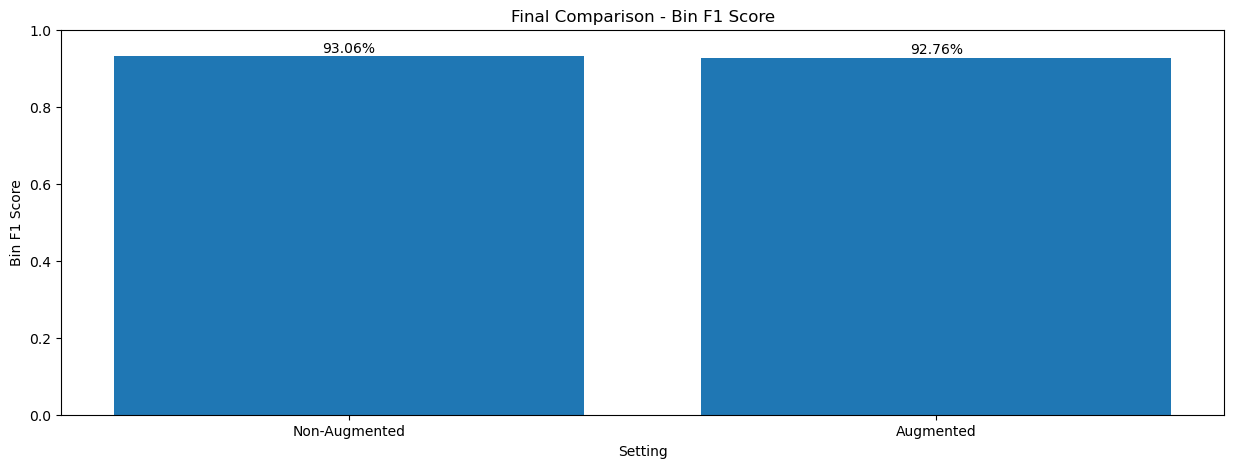

In [107]:
plt.figure(figsize=(15, 5))
bars = plt.bar(final_comparison_df_rounded["Setting"], final_comparison_df_rounded["Bin F1 Score"])

plt.xlabel("Setting")
plt.ylabel("Bin F1 Score")
plt.title("Final Comparison - Bin F1 Score")

for bar in bars:
    value = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, value + 0.002, f"{value*100:.2f}%",
             ha="center", va="bottom")

plt.ylim(0, 1)
plt.show()

### Final Model Selection

In [109]:
best_final_model_row = final_comparison_df.loc[final_comparison_df["Validation F1"].idxmax()]

print("Selected final model:")
print(best_final_model_row)

Selected final model:
Setting                                  Augmented
Model            EfficientNet_B0 with Augmentation
Validation F1                             0.939264
Test Accuracy                             0.921053
Test F1 Score                             0.914059
Bin Accuracy                              0.984211
Bin F1 Score                              0.927628
Name: 1, dtype: object


The final comparison between the best non-augmented model and the best augmented model showed mixed results. The non-augmented version, **EfficientNet_B0**, achieved a slightly higher test F1 score (**0.9155** vs **0.9141**) and a slightly higher bin-level F1 score (**0.9306** vs **0.9276**), while both models obtained the same test accuracy (**0.9211**) and bin accuracy (**0.9842**). However, the augmented version, **EfficientNet_B0 with augmentation**, achieved the highest validation F1 score (**0.9393** vs **0.9127**).

Since model selection in this notebook was based on **validation F1 score**, **EfficientNet_B0 with augmentation** was selected as the final model. This choice is also consistent with the aim of improving robustness under the variability expected in the real robot-arm scenario. At the same time, the non-augmented version was retained for practical comparison in the robotics lab, since it remained slightly stronger on some final test metrics.